# RankMixer Clean 独立学习版

这份 notebook 是自包含版本：所有配置、特征、数据准备、模型、loss、评估和训练逻辑都写在 notebook 内部，不依赖 `rec/` 文件夹运行。它的组织方式接近 `6.ranking.ipynb`：从数据开始一路跑到训练结果，同时保留中间表格，方便你边运行边理解每一步。


## 1. 导入、路径与实验配置

这一段建立全局配置。`SCENARIO_NAME` 决定本次训练使用哪种 loss/head/score 组合；下面默认就是全量数据和正式训练配置。路径默认从当前项目目录推导，输出写到 `outputs/`。


In [ ]:
from __future__ import annotations

import copy
import gc
import os
import pickle
import random
import time
from collections import OrderedDict, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Sequence

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import ndcg_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, Dataset

PROJECT_ROOT = Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = Path(os.getenv("FUNREC_RAW_DATA_PATH", DATA_DIR / "raw")).resolve()
DATA_PATH = RAW_DATA_DIR if RAW_DATA_DIR.name == "news_recommendation" else RAW_DATA_DIR / "news_recommendation"
PROCESSED_DATA_DIR = Path(os.getenv("FUNREC_PROCESSED_DATA_PATH", DATA_DIR / "processed")).resolve()
SAVE_PATH = Path(os.getenv("FUNREC_SAVE_PATH", PROCESSED_DATA_DIR / "temp_results")).resolve()
OUTPUT_PATH = PROJECT_ROOT / "outputs"

TRAIN_FEATURE_FILES = {
    "baseline": "trn_user_item_feats_df_all.csv",
    "top64": "trn_user_item_feats_df_all_rankmixer_v2_top64.csv",
    "top100": "trn_user_item_feats_df_all_rankmixer_v2_top100.csv",
}
DEFAULT_SEED = 42


@dataclass(frozen=True)
class PathConfig:
    project_root: Path = PROJECT_ROOT
    data_path: Path = DATA_PATH
    save_path: Path = SAVE_PATH
    output_path: Path = OUTPUT_PATH


@dataclass(frozen=True)
class DataConfig:
    mode: str = "offline"
    train_variant: str = "top64"
    max_history_len: int = 50
    article_svd_dim: int = 41
    val_user_sample_size: int | None = 2000


@dataclass(frozen=True)
class ModelConfig:
    emb_dim: int = 8
    token_dim: int = 64
    num_layers: int = 2
    expansion_ratio: int = 4
    dropout_rate: float = 0.1
    pooling: str = "mean"
    logit_head_units: tuple[int, ...] = (64,)
    attention_hidden_units: tuple[int, ...] = (64, 32)


@dataclass(frozen=True)
class LossConfig:
    alpha: float = 0.5
    listwise_tau: float = 0.8
    bpr_weight: float = 0.25
    bce_aux_weight: float = 0.10
    max_neg_per_query: int = 80


@dataclass(frozen=True)
class TrainConfig:
    epochs: int = 5
    batch_size: int = 1024
    lr: float = 5e-4
    weight_decay: float = 1e-5
    grad_clip_norm: float = 1.0
    batch_log_interval: int = 1000
    topk: int = 5
    device: str | None = None


@dataclass(frozen=True)
class ExperimentConfig:
    paths: PathConfig = PathConfig()
    data: DataConfig = DataConfig()
    model: ModelConfig = ModelConfig()
    loss: LossConfig = LossConfig()
    train: TrainConfig = TrainConfig()


def train_feature_name(variant: str = "top64") -> str:
    return TRAIN_FEATURE_FILES[variant]


SCENARIO_NAME = "old_ge"
CONFIG = ExperimentConfig(
    data=DataConfig(train_variant="top64", article_svd_dim=41, val_user_sample_size=2000),
    train=TrainConfig(epochs=5, batch_size=1024, lr=5e-4, batch_log_interval=1000, topk=5, device=None),
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

print(f"project_root={CONFIG.paths.project_root}")
print(f"save_path={CONFIG.paths.save_path}")
print(f"data_path={CONFIG.paths.data_path}")
print(f"scenario={SCENARIO_NAME}")
print(CONFIG)


## 2. Scenario：本次实验到底在训练什么

Scenario 是一个很小的实验协议：它告诉后面的训练循环用哪个 loss、模型输出是 two-logit 还是 single-logit，以及验证时怎样把 raw output 转成排序分数。这里直接用 `SCENARIO_NAME` 取出当前实验。


In [ ]:
@dataclass(frozen=True)
class Scenario:
    """一次实验的最小配置：loss 名称、模型输出头类型，以及如何把 raw output 解释成排序分数。"""

    name: str
    loss_name: str
    head_type: str
    score_mode: str


DEFAULT_SCENARIOS = {
    "old_ge": Scenario("old_ge", "old_ge", "two_logit", "diff"),
    "query_softmax_ce": Scenario("query_softmax_ce", "query_softmax_ce", "single_logit", "scalar"),
    "listwise_bpr_bce": Scenario("listwise_bpr_bce", "listwise_bpr_bce", "single_logit", "scalar"),
}

scenario = DEFAULT_SCENARIOS[SCENARIO_NAME]
scenario_df = pd.DataFrame(
    {
        "scenario": item.name,
        "loss": item.loss_name,
        "head_type": item.head_type,
        "score_mode": item.score_mode,
    }
    for item in DEFAULT_SCENARIOS.values()
)
display(scenario_df)
scenario


## 3. 特征定义与 RankMixer token schema

这一大段定义 sparse 特征、dense 特征、rank/score 派生特征、文章内容 SVD 特征，以及 RankMixer 的 token schema。重点看 `build_dense_token_groups` 和 `build_token_specs`：未被业务分组覆盖的 dense 特征进入 `dense_residual`，历史行为单独进入 `history_token`，最后明确 `return specs`。


In [42]:
HISTORY_FEATURE = 'hist_click_article_id'

META_INT_FEATURES = ('query_id',)

META_FLOAT_FEATURES = ('sample_prob',)

BASE_SPARSE_FEATURES = ('click_article_id', 'category_id', 'click_environment', 'click_deviceGroup', 'click_os', 'click_country', 'click_region', 'click_referrer_type')

RANK_SCORE_SPARSE_FEATURES = ('rank_bucket',)

BASE_DENSE_FEATURES = ('sim0', 'time_diff0', 'word_diff0', 'sim_max', 'sim_min', 'sim_sum', 'sim_mean', 'score', 'rank', 'click_size', 'time_diff_mean', 'active_level', 'created_at_ts', 'user_time_hob1', 'user_time_hob2', 'words_hbo', 'words_count', 'is_cat_hab', 'article_hot_level', 'article_user_num', 'article_time_diff_mean')

RANK_SCORE_DENSE_FEATURES = ('rank_recip', 'rank_log1p', 'rank_pct200', 'score_user_z', 'score_user_minmax', 'score_gap_top', 'time_diff0_log1p', 'word_diff0_log1p', 'time_diff_mean_log1p', 'article_time_diff_mean_log1p')

SPARSE_TOKEN_ORDER = ('click_article_id', 'category_id', 'click_environment', 'click_deviceGroup', 'click_os', 'click_country', 'click_region', 'click_referrer_type', 'rank_bucket')

BASE_DENSE_TOKEN_GROUPS = OrderedDict([('recall_similarity_dense', ('sim0', 'time_diff0', 'word_diff0', 'sim_max', 'sim_min', 'sim_sum', 'sim_mean', 'time_diff0_log1p', 'word_diff0_log1p', 'time_diff_mean', 'time_diff_mean_log1p', 'article_time_diff_mean', 'article_time_diff_mean_log1p')), ('rank_score_dense', ('score', 'rank', 'rank_recip', 'rank_log1p', 'rank_pct200', 'score_user_z', 'score_user_minmax', 'score_gap_top')), ('ranking_meta_dense', ('click_size', 'active_level', 'created_at_ts')), ('user_article_profile_dense', ('user_time_hob1', 'user_time_hob2', 'words_hbo', 'words_count', 'is_cat_hab', 'article_hot_level', 'article_user_num'))])

@dataclass(frozen=True)
class FeaturePreset:
    """一次训练要使用的特征清单。

    sparse_features 会先映射成离散 id，再进入 embedding；dense_features 是连续数值特征。
    meta_features 是给训练/评估逻辑使用的辅助列，例如 query_id 只负责把同一用户的候选样本分组，
    不作为 user_id 语义特征喂给模型。
    """
    name: str
    sparse_features: tuple[str, ...]
    dense_features: tuple[str, ...]
    meta_features: tuple[str, ...] = META_INT_FEATURES

def dedupe(values: Sequence[str]) -> tuple[str, ...]:
    """按原顺序去重；dict.fromkeys 会保留第一次出现的位置。"""
    return tuple(dict.fromkeys(values))

def article_svd_features(dim: int) -> tuple[str, ...]:
    """生成文章内容 embedding 降维后的列名，例如 article_svd_0。"""
    return tuple((f'article_svd_{index}' for index in range(dim)))

def build_feature_preset(name: str='rankmixer_main', article_svd_dim: int=41) -> FeaturePreset:
    """组合默认的稀疏特征、稠密特征和文章 SVD 特征。"""
    sparse = BASE_SPARSE_FEATURES + RANK_SCORE_SPARSE_FEATURES
    dense = BASE_DENSE_FEATURES + RANK_SCORE_DENSE_FEATURES + article_svd_features(article_svd_dim)
    return FeaturePreset(name=name, sparse_features=dedupe(sparse), dense_features=dedupe(dense))

def build_dense_token_groups(preset: FeaturePreset, article_svd_dim: int=41) -> OrderedDict[str, tuple[str, ...]]:
    """把稠密特征按业务含义分组，后续模型会把每组当成一个 dense token。"""
    available = set(preset.dense_features)
    groups: OrderedDict[str, tuple[str, ...]] = OrderedDict()
    used: set[str] = set()
    for (token_name, features) in BASE_DENSE_TOKEN_GROUPS.items():
        selected = tuple((feature for feature in features if feature in available and feature not in used))
        if selected:
            groups[token_name] = selected
            used.update(selected)
    svd_group = tuple((feature for feature in article_svd_features(article_svd_dim) if feature in available))
    if svd_group:
        groups['article_content_dense'] = svd_group
        used.update(svd_group)
    residual = tuple((feature for feature in preset.dense_features if feature not in used))
    if residual:
        groups['dense_residual'] = residual
    return groups

def build_token_specs(preset: FeaturePreset, article_svd_dim: int=41) -> list[dict[str, object]]:
    """生成模型 token 配置：每个稀疏列一个 token，稠密列按组打包，历史序列单独成 token。"""
    specs: list[dict[str, object]] = []
    remaining_sparse = set(preset.sparse_features)
    for feature in SPARSE_TOKEN_ORDER:
        if feature in remaining_sparse:
            specs.append({'name': feature, 'kind': 'sparse', 'features': (feature,)})
            remaining_sparse.remove(feature)
    for feature in sorted(remaining_sparse):
        specs.append({'name': feature, 'kind': 'sparse', 'features': (feature,)})
    for (token_name, features) in build_dense_token_groups(preset, article_svd_dim).items():
        specs.append({'name': token_name, 'kind': 'dense', 'features': features})
    specs.append({'name': 'history_token', 'kind': 'history', 'features': (HISTORY_FEATURE,)})
    return specs

def ensure_feature_columns(df: pd.DataFrame, preset: FeaturePreset) -> pd.DataFrame:
    """补齐并规范化训练所需列。

    pd.to_numeric(..., errors="coerce") 会把无法转成数字的值变成 NaN；
    后面的 fillna/astype 再把缺失值落到稳定的默认值和 dtype，方便后续转 numpy。
    """
    df = df.copy()
    for feature in preset.sparse_features:
        if feature not in df.columns:
            df[feature] = 0
        df[feature] = pd.to_numeric(df[feature], errors='coerce').fillna(0).astype('int64')
    for feature in preset.dense_features:
        if feature not in df.columns:
            df[feature] = 0.0
        df[feature] = pd.to_numeric(df[feature], errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(0.0).astype('float32')
    if 'sample_prob' not in df.columns:
        df['sample_prob'] = 1.0
    df['sample_prob'] = pd.to_numeric(df['sample_prob'], errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(1.0).clip(0.0001, 1.0).astype('float32')
    return df

def add_rank_score_features(df: pd.DataFrame) -> pd.DataFrame:
    """基于召回分数和同一用户内的排序位置，追加 ranking 相关特征。

    这里的 user_id 只用来做同用户候选集合内的统计和排序，不会直接作为模型输入特征。
    groupby("user_id") 表示按用户分组计算；cumcount() 是每个分组内部从 0 开始的行号。
    """
    df = df.copy()
    score = pd.to_numeric(df['score'], errors='coerce').fillna(0.0)
    if 'rank' in df.columns:
        rank = pd.to_numeric(df['rank'], errors='coerce').fillna(0.0)
    else:
        work = pd.DataFrame({'user_id': df['user_id'], 'score': score, 'row': np.arange(len(df))})
        work = work.sort_values(['user_id', 'score', 'row'], ascending=[True, False, True], kind='mergesort')
        work['rank'] = work.groupby('user_id', sort=False).cumcount()
        rank = pd.Series(work.sort_values('row', kind='mergesort')['rank'].to_numpy(), index=df.index)
    rank = rank.clip(lower=0.0)
    df['rank'] = rank.astype('float32')
    df['rank_recip'] = (1.0 / (rank + 1.0)).astype('float32')
    df['rank_log1p'] = np.log1p(rank).astype('float32')
    df['rank_pct200'] = (rank / 199.0).astype('float32')
    df['rank_bucket'] = pd.cut(rank, bins=[-1, 0, 1, 2, 3, 4, 5, 10, 20, 50, 100, 200, 10 ** 12], labels=False).fillna(0).astype('int64')
    score_frame = pd.DataFrame({'user_id': df['user_id'], 'score': score}, index=df.index)
    stats = score_frame.groupby('user_id', sort=False)['score'].agg(['mean', 'std', 'min', 'max'])
    df = df.join(stats, on='user_id', rsuffix='_user')
    df['score_user_z'] = ((score - df['mean']) / (df['std'].fillna(0.0) + 1e-06)).astype('float32')
    df['score_user_minmax'] = ((score - df['min']) / (df['max'] - df['min'] + 1e-06)).astype('float32')
    df['score_gap_top'] = (df['max'] - score).astype('float32')
    df = df.drop(columns=['mean', 'std', 'min', 'max'])
    log_sources = {'time_diff0': 'time_diff0_log1p', 'word_diff0': 'word_diff0_log1p', 'time_diff_mean': 'time_diff_mean_log1p', 'article_time_diff_mean': 'article_time_diff_mean_log1p'}
    for (source, target) in log_sources.items():
        values = pd.to_numeric(df[source], errors='coerce').fillna(0.0) if source in df.columns else 0.0
        df[target] = np.log1p(np.clip(values, 0.0, None)).astype('float32')
    return df

def load_article_embedding(data_path: Path, save_path: Path) -> pd.DataFrame:
    """读取文章内容向量，并统一整理成 click_article_id + article_emb_* 的 DataFrame。"""
    pkl_path = save_path / 'item_content_emb_all.pkl'
    if pkl_path.exists():
        import pickle
        with pkl_path.open('rb') as file:
            embedding_dict = pickle.load(file)
        item_ids = np.asarray(list(embedding_dict.keys()), dtype=np.int64)
        matrix = np.asarray([np.asarray(value, dtype=np.float32).reshape(-1) for value in embedding_dict.values()])
        df = pd.DataFrame(matrix, columns=[f'article_emb_{index}' for index in range(matrix.shape[1])])
        df.insert(0, 'click_article_id', item_ids)
        return df
    df = pd.read_csv(data_path / 'articles_emb.csv')
    id_col = 'click_article_id' if 'click_article_id' in df.columns else 'article_id'
    df = df.rename(columns={id_col: 'click_article_id'})
    numeric_cols = [column for column in df.select_dtypes(include=[np.number]).columns if column != 'click_article_id']
    emb_cols = [column for column in numeric_cols if 'emb' in column.lower()] or numeric_cols
    matrix = df[emb_cols].to_numpy(dtype=np.float32)
    matrix = matrix / (np.linalg.norm(matrix, axis=1, keepdims=True) + 1e-12)
    out = pd.DataFrame(matrix, columns=[f'article_emb_{index}' for index in range(matrix.shape[1])])
    out.insert(0, 'click_article_id', pd.to_numeric(df['click_article_id'], errors='coerce').fillna(0).astype('int64'))
    return out

def add_article_svd_features(frames: Sequence[pd.DataFrame | None], data_path: Path, save_path: Path, n_components: int, seed: int=DEFAULT_SEED) -> tuple[pd.DataFrame | None, ...]:
    """把高维文章 embedding 用 TruncatedSVD 降维后 merge 到候选样本。

    merge(..., on="click_article_id", how="left") 表示按文章 id 左连接：
    候选样本一行不丢，找不到 embedding 的文章后面用 0.0 补齐。
    """
    if n_components <= 0:
        return tuple(frames)
    article_embedding = load_article_embedding(data_path, save_path)
    emb_cols = [column for column in article_embedding.columns if column.startswith('article_emb_')]
    svd = TruncatedSVD(n_components=n_components, random_state=seed)
    matrix = svd.fit_transform(article_embedding[emb_cols].to_numpy(dtype=np.float32)).astype('float32')
    svd_df = pd.DataFrame(matrix, columns=list(article_svd_features(n_components)))
    svd_df.insert(0, 'click_article_id', article_embedding['click_article_id'].astype('int64').to_numpy())
    merged_frames: list[pd.DataFrame | None] = []
    for frame in frames:
        if frame is None:
            merged_frames.append(None)
            continue
        merged = frame.copy()
        if 'article_id' in merged.columns and 'click_article_id' not in merged.columns:
            merged = merged.rename(columns={'article_id': 'click_article_id'})
        merged = merged.merge(svd_df, on='click_article_id', how='left')
        merged[list(article_svd_features(n_components))] = merged[list(article_svd_features(n_components))].fillna(0.0)
        merged_frames.append(merged)
    return tuple(merged_frames)


## 4. 查看本次实验的特征组和 token 表

这一段不会训练，只是把当前 scenario 的特征清单展开成表。建议重点看 `token_schema_df`：每一行就是 RankMixer 输入序列中的一个 token，后面的模型会把这些 token 做无参数 token mixing。


In [43]:
preset = build_feature_preset(name=scenario.name, article_svd_dim=CONFIG.data.article_svd_dim)
dense_token_groups = build_dense_token_groups(preset, CONFIG.data.article_svd_dim)
token_specs = build_token_specs(preset, CONFIG.data.article_svd_dim)

token_schema_df = pd.DataFrame(
    {
        "token_index": idx,
        "token_name": spec["name"],
        "kind": spec["kind"],
        "features": ", ".join(spec["features"]),
    }
    for idx, spec in enumerate(token_specs, start=1)
)

print(f"sparse feature count: {len(preset.sparse_features)}")
print(f"dense feature count: {len(preset.dense_features)}")
print(f"token count: {len(token_specs)}")
print(f"dense token groups: {list(dense_token_groups)}")
display(token_schema_df)


sparse feature count: 9
dense feature count: 72
token count: 15
dense token groups: ['recall_similarity_dense', 'rank_score_dense', 'ranking_meta_dense', 'user_article_profile_dense', 'article_content_dense']


,token_index,token_name,kind,features
0,1,click_article_id,sparse,click_article_id
1,2,category_id,sparse,category_id
2,3,click_environment,sparse,click_environment
3,4,click_deviceGroup,sparse,click_deviceGroup
4,5,click_os,sparse,click_os
5,6,click_country,sparse,click_country
6,7,click_region,sparse,click_region
7,8,click_referrer_type,sparse,click_referrer_type
8,9,rank_bucket,sparse,rank_bucket
9,10,recall_similarity_dense,dense,"sim0, time_diff0, word_diff0, sim_max, sim_min..."


特征分析，kmeans

## 5. 数据读取、历史合并和 DataLoader 工具

这一段定义从 CSV 读入 train/val/test、构造用户历史序列、建立 sparse id 映射、归一化 dense 特征，并把 pandas DataFrame 转成 PyTorch DataLoader 输入的所有工具函数。`query_id` 只用于同用户候选集合分组，不作为模型语义特征。


In [ ]:
PAD_IDX = 0#PAD_IDX 是 padding 用的编号，比如历史点击序列不够长时补 0。

OOV_IDX = 1#OOV_IDX 是 unknown / out-of-vocabulary，用来表示验证集或测试集里出现了训练词表没见过的文章 id。



@dataclass
class LoadedFrames:
    """从磁盘读入的原始特征表集合。
    train/val/test 是候选样本表，history 是用户历史点击表；此阶段还没有把历史序列拼到候选样本上。
    """
    train: pd.DataFrame
    val: pd.DataFrame | None
    test: pd.DataFrame
    history: pd.DataFrame

@dataclass
class MergedFrames:
    """已经补好 query_id 和历史点击序列的样本表集合。"""
    train: pd.DataFrame
    val: pd.DataFrame | None
    test: pd.DataFrame
    val_hit_mask: pd.Series | None
    val_hit_frame: pd.DataFrame | None


#sample_validation_frame 是为了加速实验验证；它只缩小 val，不缩小 train；后面会用于每个 epoch 的评估和 best model 选择。
def sample_validation_frame(frames: LoadedFrames, n_users: int | None, seed: int=DEFAULT_SEED) -> LoadedFrames:
    """按 user 抽完整验证query，训练集保持全量。
    验证集太大时，只随机抽一部分用户来做验证，但每个被抽中的用户，其所有候选文章都保留下来。
    训练集、测试集、历史点击都不动。"""
    if frames.val is None or n_users is None:
        return frames
    users = frames.val["user_id"].drop_duplicates()
    if len(users) <= n_users:
        return frames
    selected = set(users.sample(n=n_users, random_state=seed).tolist())
    val = frames.val[frames.val["user_id"].isin(selected)].copy()
    return LoadedFrames(train=frames.train, val=val, test=frames.test, history=frames.history)

@dataclass
class PreparedRankingData:
    """训练前的最终数据包。

    *_frame 保留 pandas 版本，便于调试和评估；x_* 是已经转成 numpy 的模型输入字典；
    y_* 是 label 数组；sparse_maps/scalers 记录离散映射和连续特征归一化器，供验证/测试复用。
    """
    train_frame: pd.DataFrame
    val_frame: pd.DataFrame | None
    test_frame: pd.DataFrame
    val_hit_mask: pd.Series | None
    val_hit_frame: pd.DataFrame | None
    x_train: dict[str, np.ndarray]
    y_train: np.ndarray
    x_val: dict[str, np.ndarray] | None
    y_val: np.ndarray | None
    x_test: dict[str, np.ndarray] | None
    sparse_maps: dict[str, dict[int, int]]#稀疏特征映射表
    sparse_vocab_sizes: dict[str, int]#embedding 词表大小
    dense_scalers: dict[str, MinMaxScaler]#连续特征归一化器
    feature_preset: FeaturePreset#当前使用的特征配置

class RankingDataset(Dataset):
    """把 numpy input dict 包成 PyTorch Dataset。
    x_dict的每个key是一个特征名，每个value的第0维都对应样本行号。
    """

    def __init__(self, x_dict: dict[str, np.ndarray], y: np.ndarray | None=None):
        self.x_dict = x_dict #x_dict 是所有特征。
        self.y = y #y 是 label，可以有，也可以没有。
        self.length = len(next(iter(x_dict.values())))#这行是在计算数据集长度，也就是一共有多少条样本。


    def __len__(self) -> int:
        return self.length
    def __getitem__(self, index: int):
        sample = {key: value[index] for (key, value) in self.x_dict.items()}
        #它遍历所有特征，然后每个特征都取第 index 行。
        if self.y is None:
            return sample
        return (sample, self.y[index])#(sample, label)


class QueryBatchSampler:
    """按 query_id 组织 batch，使用 numpy 边界避免为每行创建 Python list。
       把所有样本按照 query_id 分成一块一块的 query block。
       把样本按照 query_id 分组，并且在生成 batch 时尽量保证同一个 query_id 的样本不会被拆开。
       也就是说，它不是简单地每 batch_size 条样本切一个 batch，而是先把相同 query_id 的样本聚成一个 query block，然后把若干个 query block 拼成一个 batch。
    """
    def __init__(self, query_ids: Sequence[int], batch_size: int, shuffle: bool=True, seed: int | None=None):
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.seed = seed
        self.epoch = 0

        query_ids = np.asarray(query_ids)#每条样本对应的 query 分组 id。

        if query_ids.size and np.all(query_ids[1:] >= query_ids[:-1]):
        #判断 query_ids 是否已经是升序排列。
            self.order = np.arange(query_ids.size, dtype=np.int64)
            sorted_query_ids = query_ids
        else:
            self.order = np.argsort(query_ids, kind='mergesort')
            #这一步会按照 query_id 对样本重新排序。相同 query_id 内部，尽量保持原来的相对顺序。
            sorted_query_ids = query_ids[self.order]

        if sorted_query_ids.size == 0:
            self.starts = np.asarray([], dtype=np.int64)
            self.ends = np.asarray([], dtype=np.int64)
        else:
            boundaries = np.flatnonzero(sorted_query_ids[1:] != sorted_query_ids[:-1]) + 1
            # 找 query_id 变化的位置，这些位置就是不同 query block 的边界。
            self.starts = np.concatenate(([0], boundaries)).astype(np.int64)
            self.ends = np.concatenate((boundaries, [sorted_query_ids.size])).astype(np.int64)
        self.block_sizes = self.ends - self.starts

    def _block(self, block_index: int) -> np.ndarray: #取出某个 query block 的原始样本索引
        return self.order[self.starts[block_index]:self.ends[block_index]]
   
    def _block_order(self) -> np.ndarray:#决定 query block 的遍历顺序
        block_order = np.arange(len(self.starts), dtype=np.int64)
        if self.shuffle and block_order.size:
            rng = np.random.default_rng(None if self.seed is None else self.seed + self.epoch)
            rng.shuffle(block_order)
        return block_order

    def __iter__(self):
        block_order = self._block_order()
        self.epoch += 1

        batch_parts: list[np.ndarray] = []
        batch_size = 0
        for block_index in block_order:
            block = self._block(int(block_index))
            block_size = int(block.size)
            if block_size >= self.batch_size:#当前 query block 自己就大于等于 batch_size
                if batch_parts:
                    yield np.concatenate(batch_parts).tolist()
                    batch_parts = []
                    batch_size = 0
                yield block.tolist()
                continue
            if batch_size + block_size > self.batch_size:
                #第二种情况：当前 block 放进去会超过 batch_size。
                yield np.concatenate(batch_parts).tolist()
                batch_parts = [block]
                batch_size = block_size
            else:
                # 第三种情况：当前 block 可以放进当前 batch。
                batch_parts.append(block)
                batch_size += block_size
        if batch_parts:
            yield np.concatenate(batch_parts).tolist()

    def __len__(self) -> int:
    #计算这个 sampler 一共会产生多少个 batch。
        count = 0
        size = 0
        for block_index in self._block_order():
            block_size = int(self.block_sizes[int(block_index)])
            if block_size >= self.batch_size:
                count += 1 + int(size > 0)
                size = 0
            elif size + block_size > self.batch_size:
                count += 1
                size = block_size
            else:
                size += block_size
        return count + int(size > 0)

def tensor_dtype(array: np.ndarray) -> torch.dtype:
    return torch.long if np.issubdtype(array.dtype, np.integer) else torch.float32

def collate_features(batch: Sequence[dict[str, Any]]) -> dict[str, torch.Tensor]:
    """把 Dataset 取出的多条样本拼成一个 batch tensor 字典。"""
    return {key: torch.tensor(np.stack([sample[key] for sample in batch]), dtype=tensor_dtype(np.asarray(batch[0][key]))) for key in batch[0]}

# collate_with_labels 是专门给有 label 的情况用的，它会把 features 和 labels 分开处理，features 用 collate_features 拼成 tensor 字典，labels 则单独拼成一个 float32 的 tensor。
def collate_with_labels(batch: Sequence[tuple[dict[str, Any], Any]]) -> tuple[dict[str, torch.Tensor], torch.Tensor]:
    (features, labels) = zip(*batch)
    return (collate_features(features), torch.tensor(np.asarray(labels), dtype=torch.float32))

def make_loader(x_dict: dict[str, np.ndarray], y: np.ndarray | None=None, batch_size: int=256, shuffle: bool=False, group_by_query: bool=False, seed: int | None=None) -> DataLoader:
    """创建 PyTorch DataLoader；训练时可选择按 query_id 保持候选集合分组。"""
    dataset = RankingDataset(x_dict, y)
    if y is None:
        return DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_features)
    if group_by_query:
        sampler = QueryBatchSampler(x_dict['query_id'], batch_size=batch_size, shuffle=shuffle, seed=seed)
        return DataLoader(dataset, batch_sampler=sampler, collate_fn=collate_with_labels)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_with_labels)

def move_batch_to_device(batch: dict[str, torch.Tensor], device: torch.device) -> dict[str, torch.Tensor]:
    return {key: value.to(device) for (key, value) in batch.items()}

def read_csv(path: Path) -> pd.DataFrame:
    return pd.read_csv(path)


def load_feature_frames(paths: PathConfig, config: DataConfig) -> LoadedFrames:
    """加载全量 train/val/test 候选特征、历史点击和文章内容特征。"""

    train = read_csv(paths.save_path / train_feature_name(config.train_variant))
    val = read_csv(paths.save_path / "val_user_item_feats_df_all.csv")
    test = read_csv(paths.save_path / "tst_user_item_feats_df_all.csv")
    history = read_csv(paths.save_path / "click_hist_all.csv")

    train, val, test = [add_rank_score_features(frame) for frame in (train, val, test)]
    train, val, test = add_article_svd_features(
        (train, val, test),
        paths.data_path,
        paths.save_path,
        config.article_svd_dim,
    )
    return LoadedFrames(train=train, val=val, test=test, history=history)


def add_query_id(df: pd.DataFrame) -> pd.DataFrame:
    """补 query_id 列。

    query_id 当前取自 user_id，只用于 DataLoader/排序损失的“同组候选”标识。
    user_id 本身不会进入模型特征；这里也不会把它加入 FeaturePreset。
    """
    df = df.copy()
    if 'article_id' in df.columns and 'click_article_id' not in df.columns:
        df = df.rename(columns={'article_id': 'click_article_id'})
    df['query_id'] = pd.to_numeric(df['user_id'], errors='coerce').fillna(0).astype('int64')
    return df


def build_history_sequences(history: pd.DataFrame) -> pd.DataFrame:
    """把历史点击明细压成每个用户一条点击序列。
    sort_values 先按用户和时间排序；groupby("user_id")["click_article_id"].agg(list)
    会把同一用户的文章 id 收集成 Python list，作为历史行为序列特征。
    """
    sort_cols = ['user_id'] + (['click_timestamp'] if 'click_timestamp' in history.columns else [])
    history = history.sort_values(sort_cols, kind='mergesort')
    sequences = history.groupby('user_id', sort=False)['click_article_id'].agg(list).reset_index()
    sequences[HISTORY_FEATURE] = sequences['click_article_id']
    return sequences[['user_id', HISTORY_FEATURE]]

def merge_history_frames(frames: LoadedFrames) -> MergedFrames:
    """把历史点击序列拼到 train/val/test 候选样本上。
    merge(history, on="user_id", how="left") 表示按用户左连接：每条候选样本保留，
    同一个用户会拿到同一条历史点击序列；没有历史的用户用空 list。
    """
    history = build_history_sequences(frames.history)

    def merge(frame: pd.DataFrame | None) -> pd.DataFrame | None:
        if frame is None:
            return None
        merged = add_query_id(frame).merge(history, on='user_id', how='left')
        merged[HISTORY_FEATURE] = merged[HISTORY_FEATURE].apply(lambda value: value if isinstance(value, list) else [])
        return merged
    train = merge(frames.train)
    val = merge(frames.val)
    test = merge(frames.test) if len(frames.test) else add_query_id(frames.test.copy())
    val_hit_mask = val.groupby('query_id')['label'].transform('max').eq(1) if val is not None and 'label' in val else None
    val_hit_frame = val[val_hit_mask].copy() if val_hit_mask is not None else None
    return MergedFrames(train=train, val=val, test=test, val_hit_mask=val_hit_mask, val_hit_frame=val_hit_frame)

def normalize_dense_features(train: pd.DataFrame, val: pd.DataFrame | None, test: pd.DataFrame, dense_features: Sequence[str]) -> dict[str, MinMaxScaler]:
    """用训练集拟合连续特征归一化器，并复用到 val/test。
    fit_transform 只在 train 上学习 min/max；val/test 只 transform，避免验证/测试信息泄漏。
    scalers = normalize_dense_features(train, val, test, preset.dense_features)
    """
    scalers: dict[str, MinMaxScaler] = {}
    for feature in dense_features:
        scaler = MinMaxScaler()
        train[feature] = scaler.fit_transform(train[[feature]]).astype('float32')
        if val is not None:
            val[feature] = scaler.transform(val[[feature]]).astype('float32')
        if len(test):
            test[feature] = scaler.transform(test[[feature]]).astype('float32')
        scalers[feature] = scaler
    return scalers

def build_sparse_maps(frames: Sequence[pd.DataFrame], sparse_features: Sequence[str], history_feature: str=HISTORY_FEATURE) -> dict[str, dict[int, int]]:
    """为每个稀疏特征建立“原始取值 -> 连续 id”的映射。
    click_article_id 同时出现在候选文章和历史序列里，所以要把历史里的文章 id 也加入词表。
    0 预留给 PAD，1 预留给 OOV，方便处理补齐和未知文章。
    """
    sparse_maps: dict[str, dict[int, int]] = {}
    for feature in sparse_features:
        values = pd.concat([pd.to_numeric(frame[feature], errors='coerce').fillna(0).astype('int64') for frame in frames], ignore_index=True)
        unique_values = set((int(value) for value in values.tolist() if int(value) != 0))
        if feature == 'click_article_id':
            for frame in frames:
                for sequence in frame[history_feature].tolist():
                    unique_values.update((int(value) for value in sequence if int(value) != 0))
            sparse_maps[feature] = {value: index for (index, value) in enumerate(sorted(unique_values), start=OOV_IDX + 1)}
        else:
            sparse_maps[feature] = {value: index for (index, value) in enumerate(sorted(unique_values), start=1)}
    return sparse_maps

def sparse_vocab_sizes(sparse_maps: dict[str, dict[int, int]], sparse_features: Sequence[str]) -> dict[str, int]:
    sizes: dict[str, int] = {}
    for feature in sparse_features:
        minimum = OOV_IDX + 1 if feature == 'click_article_id' else 1
        sizes[feature] = max(max(sparse_maps[feature].values(), default=minimum - 1) + 1, minimum)
    return sizes

def map_sparse(series: pd.Series, mapping: dict[int, int], feature: str) -> np.ndarray:
    """把 pandas Series 中的原始稀疏取值映射成 numpy int64 id 数组。"""
    values = pd.to_numeric(series, errors='coerce').fillna(0).astype('int64')
    default = OOV_IDX if feature == 'click_article_id' else PAD_IDX
    return values.map(mapping).fillna(default).astype('int64').to_numpy()

def pad_sequences(sequences: Sequence[Sequence[int]], maxlen: int) -> np.ndarray:
    """把不等长历史序列补齐成二维数组，只保留最近 maxlen 个点击。"""
    padded = np.zeros((len(sequences), maxlen), dtype=np.int64)
    for (index, sequence) in enumerate(sequences):
        recent = list(sequence)[-maxlen:]
        if recent:
            padded[index, -len(recent):] = np.asarray(recent, dtype=np.int64)
    return padded

def map_history(sequences: Sequence[Sequence[int]], item_mapping: dict[int, int], maxlen: int) -> np.ndarray:
    """把历史文章 id 序列映射成 embedding id，并做 padding。"""
    mapped_sequences: list[list[int]] = []
    for sequence in sequences:
        mapped_sequences.append([item_mapping.get(int(item_id), OOV_IDX) for item_id in sequence if int(item_id) != 0])
    return pad_sequences(mapped_sequences, maxlen)

def build_model_input(frame: pd.DataFrame, sparse_maps: dict[str, dict[int, int]], preset: FeaturePreset, max_history_len: int) -> dict[str, np.ndarray]:
    """把一个 DataFrame split 转成模型需要的 numpy input dict。

    这里是从 pandas 到模型输入的关键转换：
    稀疏列先过 sparse_maps 变成 int64 id，连续列直接转 float32 numpy，
    query_id/sample_prob 等 meta 列也放进字典供训练流程使用；历史序列转成 [样本数, max_history_len]。
    """
    x: dict[str, np.ndarray] = {}
    for feature in preset.sparse_features:
        x[feature] = map_sparse(frame[feature], sparse_maps[feature], feature)
    for feature in preset.dense_features:
        x[feature] = frame[feature].astype('float32').to_numpy()
    for feature in preset.meta_features:
        x[feature] = frame[feature].astype('int64').to_numpy()
    for feature in META_FLOAT_FEATURES:
        x[feature] = frame[feature].astype('float32').to_numpy()
    x[HISTORY_FEATURE] = map_history(frame[HISTORY_FEATURE].tolist(), sparse_maps['click_article_id'], max_history_len)
    return x

def prepare_ranking_data(frames: MergedFrames, preset: FeaturePreset, config: DataConfig) -> PreparedRankingData:
    """完成训练前的数据准备：补列、归一化、建词表、转 numpy 输入。"""
    train = ensure_feature_columns(frames.train, preset)
    val = ensure_feature_columns(frames.val, preset) if frames.val is not None else None
    test = ensure_feature_columns(frames.test, preset) if len(frames.test) else frames.test.copy()
    scalers = normalize_dense_features(train, val, test, preset.dense_features)
    vocab_frames = [train]
    maps = build_sparse_maps(vocab_frames, preset.sparse_features)
    vocab_sizes = sparse_vocab_sizes(maps, preset.sparse_features)
    x_train = build_model_input(train, maps, preset, config.max_history_len)
    y_train = train['label'].astype('float32').to_numpy()
    x_val = build_model_input(val, maps, preset, config.max_history_len) if val is not None else None
    y_val = val['label'].astype('float32').to_numpy() if val is not None else None
    x_test = build_model_input(test, maps, preset, config.max_history_len) if len(test) else None
    return PreparedRankingData(train_frame=train, val_frame=val, test_frame=test, val_hit_mask=frames.val_hit_mask, val_hit_frame=frames.val_hit_frame, x_train=x_train, y_train=y_train, x_val=x_val, y_val=y_val, x_test=x_test, sparse_maps=maps, sparse_vocab_sizes=vocab_sizes, dense_scalers=scalers, feature_preset=preset)


## 6. 读取全量特征数据

这里开始真正读取全量数据：训练集、验证集、测试集和历史点击表都会被加载；随后会追加 rank/score 派生特征和 article SVD 特征。运行完后先看 shape 和 train 的前几行，确认候选样本粒度。


In [45]:
loaded_frames = load_feature_frames(CONFIG.paths, CONFIG.data)

loaded_shape_df = pd.DataFrame(
    [
        {"split": "train", "shape": loaded_frames.train.shape},
        {"split": "val", "shape": None if loaded_frames.val is None else loaded_frames.val.shape},
        {"split": "test", "shape": loaded_frames.test.shape},
        {"split": "history", "shape": loaded_frames.history.shape},
    ]
)
display(loaded_shape_df)
display(loaded_frames.train.head())
print(f"train columns: {loaded_frames.train.columns.tolist()}")

,split,shape
0,train,"(7024640, 85)"
1,val,"(8000000, 83)"
2,test,"(0, 84)"
3,history,"(912623, 9)"


,user_id,click_article_id,sim0,time_diff0,word_diff0,sim_max,sim_min,sim_sum,sim_mean,score,rank,label,sample_prob,neg_bucket,click_size,time_diff_mean,active_level,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,user_time_hob1,user_time_hob2,words_hbo,category_id,created_at_ts,words_count,article_user_num,article_time_diff_mean,article_hot_level,is_cat_hab,rank_recip,rank_log1p,rank_pct200,rank_bucket,score_user_z,score_user_minmax,score_gap_top,time_diff0_log1p,word_diff0_log1p,time_diff_mean_log1p,article_time_diff_mean_log1p,article_svd_0,article_svd_1,article_svd_2,article_svd_3,article_svd_4,article_svd_5,article_svd_6,article_svd_7,article_svd_8,article_svd_9,article_svd_10,article_svd_11,article_svd_12,article_svd_13,article_svd_14,article_svd_15,article_svd_16,article_svd_17,article_svd_18,article_svd_19,article_svd_20,article_svd_21,article_svd_22,article_svd_23,article_svd_24,article_svd_25,article_svd_26,article_svd_27,article_svd_28,article_svd_29,article_svd_30,article_svd_31,article_svd_32,article_svd_33,article_svd_34,article_svd_35,article_svd_36,article_svd_37,article_svd_38,article_svd_39,article_svd_40
0,3,36162,0.646486,5148000,17,0.646486,0.646486,0.646486,0.646486,1.000000,0.0,1.0,1.000000,pos,1.000000,1.0,2.000000,4,3,2,1,25,2,0.330566,0.993039,188.0,43,1508177171000,205,0.001009,0.000021,0.00103,0.0,1.000000,0.000000,0.000000,0,1.546391,0.999999,0.000000,15.454119,2.890372,0.693147,0.000021,-0.444056,0.480962,-0.138591,0.041846,-0.236515,0.032301,0.111136,-0.041706,0.431065,-0.030855,0.074235,0.098657,0.011238,-0.1439,-0.158796,-0.018855,0.009414,-0.119764,-0.045538,0.107466,-0.181334,0.107939,0.018437,-0.020502,-0.016065,0.05591,0.108195,0.099343,0.097344,0.02531,0.024926,0.021445,0.091179,-0.000797,0.019161,-0.149652,-0.077764,0.141497,0.015509,-0.023476,-0.009533
1,5,36162,0.647237,10549000,35,0.647237,0.647237,0.647237,0.647237,0.998393,6.0,0.0,0.816327,top,1.000000,1.0,2.000000,4,4,2,1,25,2,0.330566,0.993054,240.0,43,1508177171000,205,0.001009,0.000021,0.00103,0.0,0.142857,1.945910,0.030151,6,1.372276,0.997690,0.001607,16.171541,3.583519,0.693147,0.000021,-0.444056,0.480962,-0.138591,0.041846,-0.236515,0.032301,0.111136,-0.041706,0.431065,-0.030855,0.074235,0.098657,0.011238,-0.1439,-0.158796,-0.018855,0.009414,-0.119764,-0.045538,0.107466,-0.181334,0.107939,0.018437,-0.020502,-0.016065,0.05591,0.108195,0.099343,0.097344,0.02531,0.024926,0.021445,0.091179,-0.000797,0.019161,-0.149652,-0.077764,0.141497,0.015509,-0.023476,-0.009533
2,7,36162,0.646486,5148000,17,0.646486,0.646486,0.646486,0.646486,1.000000,0.0,0.0,0.816327,top,1.000000,1.0,2.000000,4,1,17,1,25,2,0.330566,0.993039,188.0,43,1508177171000,205,0.001009,0.000021,0.00103,0.0,1.000000,0.000000,0.000000,0,1.520891,0.999999,0.000000,15.454119,2.890372,0.693147,0.000021,-0.444056,0.480962,-0.138591,0.041846,-0.236515,0.032301,0.111136,-0.041706,0.431065,-0.030855,0.074235,0.098657,0.011238,-0.1439,-0.158796,-0.018855,0.009414,-0.119764,-0.045538,0.107466,-0.181334,0.107939,0.018437,-0.020502,-0.016065,0.05591,0.108195,0.099343,0.097344,0.02531,0.024926,0.021445,0.091179,-0.000797,0.019161,-0.149652,-0.077764,0.141497,0.015509,-0.023476,-0.009533
3,9,36162,0.647237,10549000,35,0.647237,0.647237,0.647237,0.647237,0.998313,8.0,0.0,0.816327,top,0.497908,0.0,0.497908,4,3,2,1,25,2,0.330566,0.993051,217.0,43,1508177171000,205,0.001009,0.000021,0.00103,0.0,0.111111,2.197225,0.040201,6,0.924024,0.997619,0.001687,16.171541,3.583519,0.000000,0.000021,-0.444056,0.480962,-0.138591,0.041846,-0.236515,0.032301,0.111136,-0.041706,0.431065,-0.030855,0.074235,0.098657,0.011238,-0.1439,-0.158796,-0.018855,0.009414,-0.119764,-0.045538,0.107466,-0.181334,0.107939,0.018437,-0.020502,-0.016065,0.05591,0.108195,0.099343,0.097344,0.02531,0.024926,0.021445,0.091179,-0.000797,0.019161,-0.149652,-0.077764,0.141497,0.015509,-0.023476,-0.009533
4,15,36162,0.181125,25697000,29,0.181125,0.181125,0.181125,0.181125,0.997959,22.0,0.0

train columns: ['user_id', 'click_article_id', 'sim0', 'time_diff0', 'word_diff0', 'sim_max', 'sim_min', 'sim_sum', 'sim_mean', 'score', 'rank', 'label', 'sample_prob', 'neg_bucket', 'click_size', 'time_diff_mean', 'active_level', 'click_environment', 'click_deviceGroup', 'click_os', 'click_country', 'click_region', 'click_referrer_type', 'user_time_hob1', 'user_time_hob2', 'words_hbo', 'category_id', 'created_at_ts', 'words_count', 'article_user_num', 'article_time_diff_mean', 'article_hot_level', 'is_cat_hab', 'rank_recip', 'rank_log1p', 'rank_pct200', 'rank_bucket', 'score_user_z', 'score_user_minmax', 'score_gap_top', 'time_diff0_log1p', 'word_diff0_log1p', 'time_diff_mean_log1p', 'article_time_diff_mean_log1p', 'article_svd_0', 'article_svd_1', 'article_svd_2', 'article_svd_3', 'article_svd_4', 'article_svd_5', 'article_svd_6', 'article_svd_7', 'article_svd_8', 'article_svd_9', 'article_svd_10', 'article_svd_11', 'article_svd_12', 'article_svd_13', 'article_svd_14', 'article_svd_1

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif


LABEL_COL = "label"
RANDOM_STATE = 42

EXCLUDE_COLS = {
    "label",
    "user_id",
    "sample_prob",
    "neg_bucket",
}

SPARSE_FEATURES = [
    "click_article_id",
    "category_id",
    "click_environment",
    "click_deviceGroup",
    "click_os",
    "click_country",
    "click_region",
    "click_referrer_type",
    "rank_bucket",
]

feature_cols = [c for c in loaded_frames.train.columns if c not in EXCLUDE_COLS]
sparse_features = [c for c in SPARSE_FEATURES if c in feature_cols]
dense_features = [c for c in feature_cols if c not in sparse_features]

print("dense feature count:", len(dense_features))
print("sparse feature count:", len(sparse_features))
print("dense features:", dense_features)
print("sparse features:", sparse_features)


def sample_df(df, n=500_000, random_state=42):
    if df is None:
        return None
    if len(df) <= n:
        return df.copy()
    return df.sample(n=n, random_state=random_state).copy()


train_s = sample_df(loaded_frames.train, n=800_000, random_state=RANDOM_STATE)
val_s = sample_df(loaded_frames.val, n=500_000, random_state=RANDOM_STATE)

if val_s is None or LABEL_COL not in val_s.columns:
    val_s = sample_df(loaded_frames.train, n=500_000, random_state=RANDOM_STATE)

print("train_s:", train_s.shape)
print("val_s:", val_s.shape)
print("val label mean:", val_s[LABEL_COL].mean())


dense feature count: 72
sparse feature count: 9
dense features: ['sim0', 'time_diff0', 'word_diff0', 'sim_max', 'sim_min', 'sim_sum', 'sim_mean', 'score', 'rank', 'click_size', 'time_diff_mean', 'active_level', 'user_time_hob1', 'user_time_hob2', 'words_hbo', 'created_at_ts', 'words_count', 'article_user_num', 'article_time_diff_mean', 'article_hot_level', 'is_cat_hab', 'rank_recip', 'rank_log1p', 'rank_pct200', 'score_user_z', 'score_user_minmax', 'score_gap_top', 'time_diff0_log1p', 'word_diff0_log1p', 'time_diff_mean_log1p', 'article_time_diff_mean_log1p', 'article_svd_0', 'article_svd_1', 'article_svd_2', 'article_svd_3', 'article_svd_4', 'article_svd_5', 'article_svd_6', 'article_svd_7', 'article_svd_8', 'article_svd_9', 'article_svd_10', 'article_svd_11', 'article_svd_12', 'article_svd_13', 'article_svd_14', 'article_svd_15', 'article_svd_16', 'article_svd_17', 'article_svd_18', 'article_svd_19', 'article_svd_20', 'article_svd_21', 'article_svd_22', 'article_svd_23', 'article_svd

## 7. 合并历史行为并准备模型输入

这一段把用户历史点击序列 merge 到每条候选样本上，然后完成训练前的全部转换：dense 归一化、train-only sparse vocabulary、历史序列 padding、label 数组和 `x_train/x_val/x_test` 字典。这里是观察中间结果最关键的地方。


In [ ]:
experiment_frames = sample_validation_frame(loaded_frames, CONFIG.data.val_user_sample_size, DEFAULT_SEED)
merged_frames = merge_history_frames(experiment_frames)
prepared_data = prepare_ranking_data(merged_frames, preset, CONFIG.data)

prepared_shape_df = pd.DataFrame(
    [
        {"object": "train_frame", "shape": prepared_data.train_frame.shape},
        {"object": "val_frame", "shape": None if prepared_data.val_frame is None else prepared_data.val_frame.shape},
        {"object": "test_frame", "shape": prepared_data.test_frame.shape},
        {"object": "x_train features", "shape": len(prepared_data.x_train)},
        {"object": "sparse vocab tables", "shape": len(prepared_data.sparse_maps)},
    ]
)

vocab_df = pd.DataFrame(
    {"feature": feature, "vocab_size": size}
    for feature, size in prepared_data.sparse_vocab_sizes.items()
).sort_values("vocab_size", ascending=False)

display(prepared_shape_df)
display(vocab_df)
display(prepared_data.train_frame[["query_id", "user_id", "click_article_id", "label", "score", "rank", HISTORY_FEATURE]].head())


特征筛选，分析

In [48]:
from sklearn.decomposition import TruncatedSVD
energy_threshold = 0.90
article_embedding = load_article_embedding(
    CONFIG.paths.data_path,
    CONFIG.paths.save_path,
)
emb_cols = [
    c for c in article_embedding.columns
    if c.startswith("article_emb_")
]
X_article_emb = article_embedding[emb_cols].to_numpy(dtype=np.float32)
print("article embedding shape:", X_article_emb.shape)
print("original embedding dim:", len(emb_cols))
max_components = min(128, X_article_emb.shape[1] - 1)
svd_probe = TruncatedSVD(
    n_components=max_components,
    random_state=RANDOM_STATE,
)
svd_probe.fit(X_article_emb)
energy_ratio = svd_probe.explained_variance_ratio_
cum_energy = np.cumsum(energy_ratio)
if cum_energy[-1] >= energy_threshold:
    k90 = int(np.searchsorted(cum_energy, energy_threshold) + 1)
else:
    k90 = max_components
    print(
        f"Warning: first {max_components} components only explain "
        f"{cum_energy[-1]:.4f}; increase max_components if needed."
    )
energy_df = pd.DataFrame({
    "component": np.arange(1, len(cum_energy) + 1),
    "explained_variance_ratio": energy_ratio,
    "cumulative_energy": cum_energy,
})
print("k for 90% energy:", k90)
display(energy_df.iloc[max(0, k90 - 5): k90 + 5])

article embedding shape: (364047, 250)
original embedding dim: 250
k for 90% energy: 41


,component,explained_variance_ratio,cumulative_energy
36,37,0.007134,0.876213
37,38,0.006866,0.883079
38,39,0.006746,0.889825
39,40,0.006475,0.896300
40,41,0.005865,0.902165
41,42,0.005749,0.907914
42,43,0.004944,0.912858
43,44,0.004691,0.917549
44,45,0.004496,0.922044
45,46,0.004403,0.926448


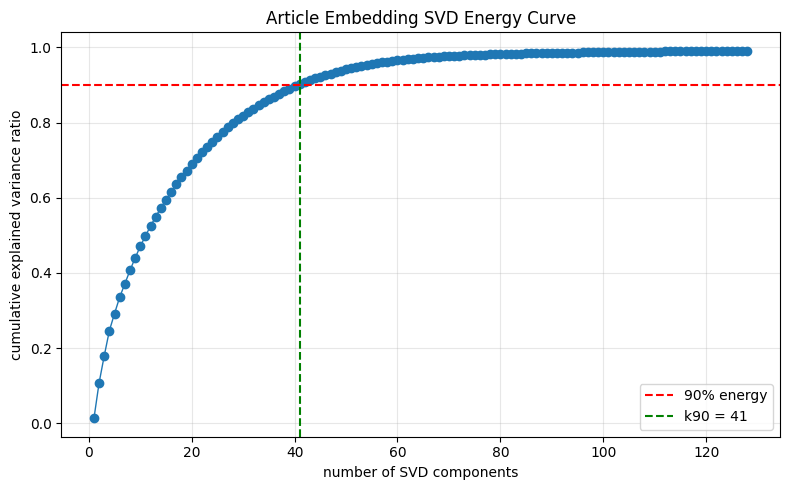

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(
    energy_df["component"],
    energy_df["cumulative_energy"],
    marker="o",
    linewidth=1,
)
plt.axhline(energy_threshold, color="red", linestyle="--", label="90% energy")
plt.axvline(k90, color="green", linestyle="--", label=f"k90 = {k90}")
plt.xlabel("number of SVD components")
plt.ylabel("cumulative explained variance ratio")
plt.title("Article Embedding SVD Energy Curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
LABEL_COL = "label"
RANDOM_STATE = 42

train_df = loaded_frames.train.copy()
val_df = loaded_frames.val.copy() if loaded_frames.val is not None else None

if val_df is None or LABEL_COL not in val_df.columns:
    val_df = train_df.sample(min(500_000, len(train_df)), random_state=RANDOM_STATE)
sparse_features = [
    c for c in preset.sparse_features
    if c in train_df.columns and c in val_df.columns
]

dense_features = [
    c for c in preset.dense_features
    if c in train_df.columns and c in val_df.columns
]

feature_cols = sparse_features + dense_features

print("feature count:", len(feature_cols))
print("dense count:", len(dense_features))
print("sparse count:", len(sparse_features))
print("dense features:", dense_features)
print("sparse features:", sparse_features)


feature count: 81
dense count: 72
sparse count: 9
dense features: ['sim0', 'time_diff0', 'word_diff0', 'sim_max', 'sim_min', 'sim_sum', 'sim_mean', 'score', 'rank', 'click_size', 'time_diff_mean', 'active_level', 'created_at_ts', 'user_time_hob1', 'user_time_hob2', 'words_hbo', 'words_count', 'is_cat_hab', 'article_hot_level', 'article_user_num', 'article_time_diff_mean', 'rank_recip', 'rank_log1p', 'rank_pct200', 'score_user_z', 'score_user_minmax', 'score_gap_top', 'time_diff0_log1p', 'word_diff0_log1p', 'time_diff_mean_log1p', 'article_time_diff_mean_log1p', 'article_svd_0', 'article_svd_1', 'article_svd_2', 'article_svd_3', 'article_svd_4', 'article_svd_5', 'article_svd_6', 'article_svd_7', 'article_svd_8', 'article_svd_9', 'article_svd_10', 'article_svd_11', 'article_svd_12', 'article_svd_13', 'article_svd_14', 'article_svd_15', 'article_svd_16', 'article_svd_17', 'article_svd_18', 'article_svd_19', 'article_svd_20', 'article_svd_21', 'article_svd_22', 'article_svd_23', 'article_s

In [51]:
def sample_df(df, n=500_000):
    if len(df) <= n:
        return df.copy()
    return df.sample(n=n, random_state=RANDOM_STATE).copy()


train_s = sample_df(train_df, 800_000)
val_s = sample_df(val_df, 500_000)

print("train sample:", train_s.shape)
print("val sample:", val_s.shape)
print("val label mean:", val_s[LABEL_COL].mean())


def clean_num(s):
    return (
        pd.to_numeric(s, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .astype("float32")
    )


train sample: (800000, 85)
val sample: (500000, 83)
val label mean: 0.003438


In [52]:
print("train only columns:", sorted(set(train_s.columns) - set(val_s.columns)))
print("val only columns:", sorted(set(val_s.columns) - set(train_s.columns)))

train only columns: ['neg_bucket', 'sample_prob']
val only columns: []


In [53]:
y_val = val_s[LABEL_COL].astype(int)
dense_rows = []
for feature in dense_features:
    x = clean_num(val_s[feature])
    if x.nunique(dropna=False) <= 1:
        continue
    auc = roc_auc_score(y_val, x)#随机拿一个正样本和一个负样本，这个特征把正样本排在负样本前面的概率。
    best_auc = max(auc, 1.0 - auc)#忽略方向，只看特征有没有区分能力
    dense_rows.append({
        "feature": feature,
        "auc": auc,
        "best_auc": best_auc,
        "direction": "higher_positive" if auc >= 0.5 else "lower_positive",
        "nunique": int(x.nunique()),
        "mean": float(x.mean()),
        "std": float(x.std()),
    })
dense_importance_df = (
    pd.DataFrame(dense_rows)
    .sort_values("best_auc", ascending=False)
    .reset_index(drop=True)
)
display(dense_importance_df)


,feature,auc,best_auc,direction,nunique,mean,std
0,time_diff0,0.090257,0.909743,lower_positive,199308,3.401989e+09,1.466801e+10
1,time_diff0_log1p,0.090257,0.909743,lower_positive,197729,1.954414e+01,2.096984e+00
2,rank,0.107995,0.892005,lower_positive,200,9.941563e+01,5.768167e+01
3,rank_recip,0.892005,0.892005,higher_positive,200,2.932463e-02,8.542812e-02
4,rank_pct200,0.107995,0.892005,lower_positive,200,4.995762e-01,2.898576e-01
...,...,...,...,...,...,...,...
67,time_diff_mean_log1p,0.501919,0.501919,higher_positive,13295,2.971061e-01,3.303410e-01
68,article_svd_15,0.498763,0.501237,lower_positive,15557,-9.442500e-03,1.224233e-01
69,user_time_hob1,0.500739,0.500739,higher_positive,20829,1.500669e-01,8.256282e-02
70,article_svd_27,0.499638,0.500362,lower_positive,15558,-1.821110e-02,8.565681e-02


,feature_a,feature_b,corr,abs_corr
0,rank,rank_pct200,1.000000,1.000000
1,sim_sum,sim0,1.000000,1.000000
2,sim_sum,sim_min,1.000000,1.000000
3,sim_sum,sim_max,1.000000,1.000000
4,sim_mean,sim0,1.000000,1.000000
...,...,...,...,...
75,score_gap_top,article_time_diff_mean,-0.250682,0.250682
76,score_user_minmax,article_hot_level,0.247687,0.247687
77,words_count,article_svd_3,0.244718,0.244718
78,article_svd_6,article_svd_19,-0.238381,0.238381


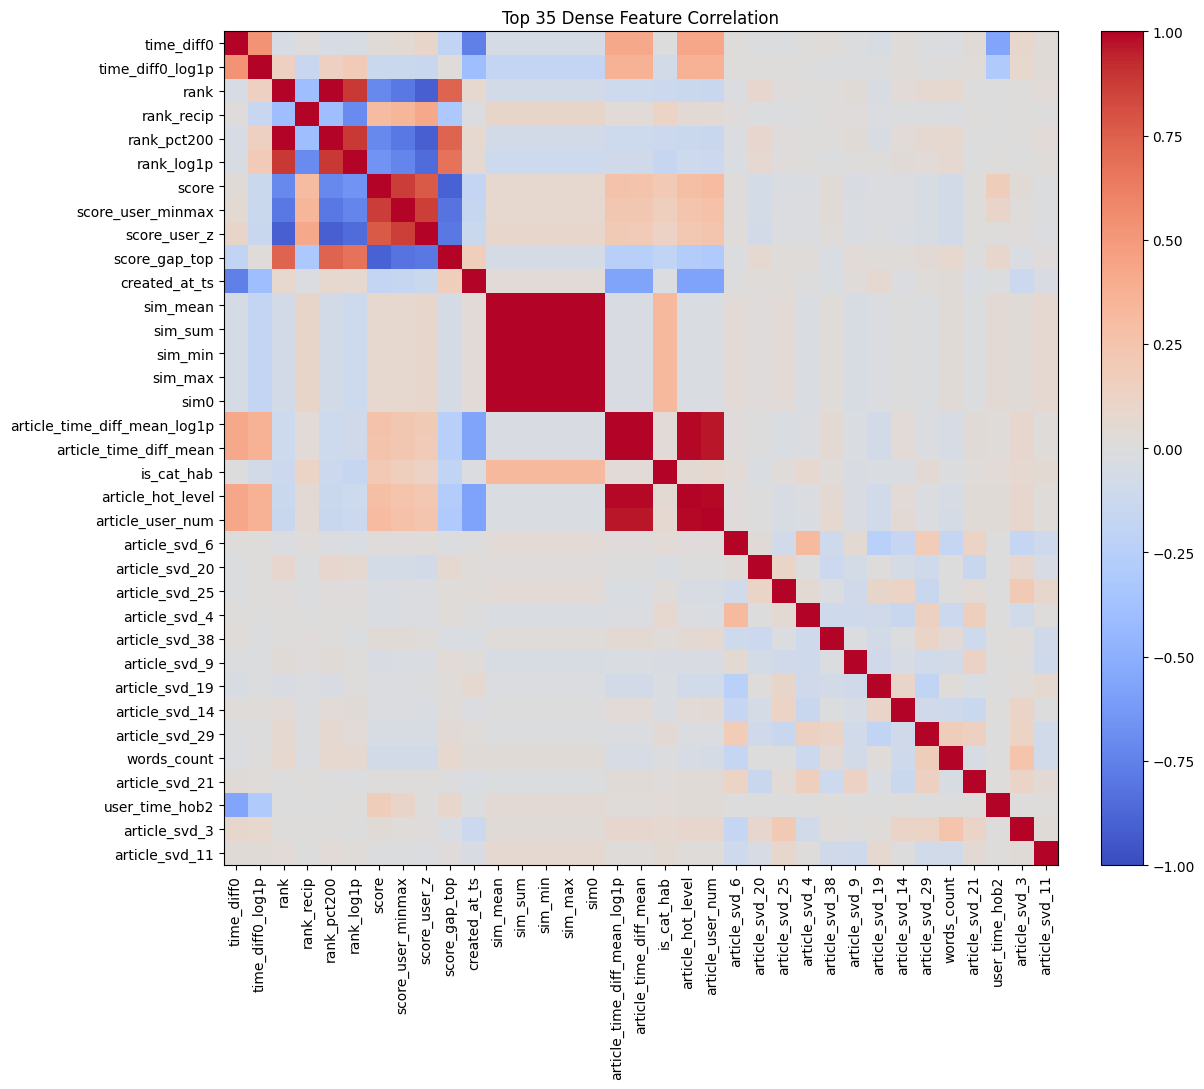

In [54]:
top_n = 35
corr_threshold = 0.90

top_dense_features = dense_importance_df.head(top_n)["feature"].tolist()

corr_df = pd.DataFrame({
    f: clean_num(val_s[f])
    for f in top_dense_features
})

corr_df = corr_df[[c for c in corr_df.columns if corr_df[c].nunique(dropna=False) > 1]]
corr = corr_df.corr(method="pearson")

features_for_corr = corr.columns.tolist()

corr_pairs = []
for i in range(len(features_for_corr)):
    for j in range(i + 1, len(features_for_corr)):
        corr_pairs.append({
            "feature_a": features_for_corr[i],
            "feature_b": features_for_corr[j],
            "corr": corr.iloc[i, j],
            "abs_corr": abs(corr.iloc[i, j]),
        })

corr_pair_df = (
    pd.DataFrame(corr_pairs)
    .sort_values("abs_corr", ascending=False)
    .reset_index(drop=True)
)

display(corr_pair_df.head(80))

plt.figure(figsize=(13, 11))

im = plt.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks(range(len(features_for_corr)), features_for_corr, rotation=90)
plt.yticks(range(len(features_for_corr)), features_for_corr)
plt.title(f"Top {len(features_for_corr)} Dense Feature Correlation")
plt.tight_layout()
plt.show()

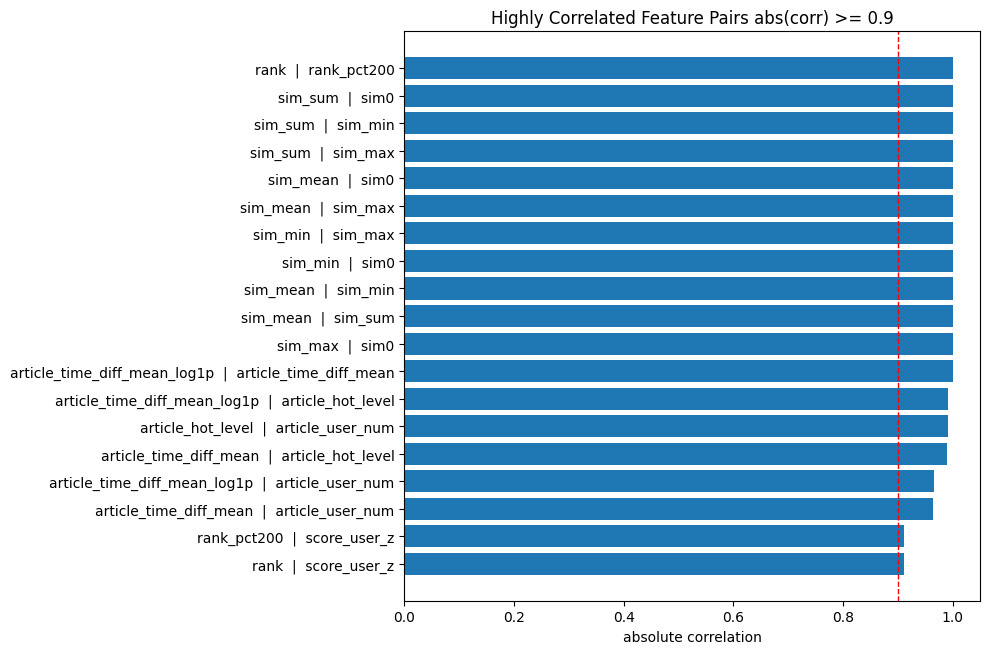

In [55]:
high_corr_plot_df = corr_pair_df[corr_pair_df["abs_corr"] >= corr_threshold].head(30).copy()
if len(high_corr_plot_df) > 0:
    high_corr_plot_df["pair"] = (
        high_corr_plot_df["feature_a"] + "  |  " + high_corr_plot_df["feature_b"]
    )
    plt.figure(figsize=(10, max(4, 0.35 * len(high_corr_plot_df))))
    plt.barh(
        high_corr_plot_df["pair"][::-1],
        high_corr_plot_df["abs_corr"][::-1],
    )
    plt.axvline(corr_threshold, color="red", linestyle="--", linewidth=1)
    plt.xlim(0, 1.05)
    plt.xlabel("absolute correlation")
    plt.title(f"Highly Correlated Feature Pairs abs(corr) >= {corr_threshold}")
    plt.tight_layout()
    plt.show()
else:
    print(f"No feature pairs with abs(corr) >= {corr_threshold}")

## 8. RankMixer 模型结构

这一段定义模型本体：DIN attention 用当前候选文章聚合历史兴趣，FieldwiseTokenization 把 sparse/dense/history 变成 token 序列，RankMixer block 做 reshape/transpose 式 token mixing，最后输出 two-logit 或 single-logit 分数。


In [56]:
class MLP(nn.Module):
    """通用多层感知机。

    业务上用于把拼好的特征表示继续压缩/变换；输入通常是 `[B, D]`，
    其中 `B` 是 batch 内样本数，`D` 是当前表示维度。
    """

    def __init__(self, input_dim: int, hidden_units: Sequence[int], dropout_rate: float=0.0):
        super().__init__()
        layers: list[nn.Module] = []
        prev_dim = input_dim
        for units in hidden_units:
            layers.extend([nn.Linear(prev_dim, units), nn.ReLU()])
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            prev_dim = units
        self.layers = nn.Sequential(*layers)
        self.output_dim = prev_dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layers(x)

class DINAttentionPooling(nn.Module):
    """DIN 风格的历史行为注意力池化。

    query_emb 表示当前候选文章，shape 为 `[B, E]`；hist_emb 表示用户历史点击文章序列，
    shape 为 `[B, H, E]`；mask 标记哪些历史位置是真实文章而不是 padding，shape 为 `[B, H]`。
    输出是每个用户历史序列围绕当前候选文章聚合后的兴趣向量，shape 为 `[B, E]`。
    """

    def __init__(self, emb_dim: int, hidden_units: Sequence[int]):
        super().__init__()
        self.att_mlp = MLP(emb_dim * 4, hidden_units)
        self.out = nn.Linear(self.att_mlp.output_dim, 1)

    def forward(self, query_emb: torch.Tensor, hist_emb: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        query = query_emb.unsqueeze(1).expand_as(hist_emb)
        att_input = torch.cat([query, hist_emb, query - hist_emb, query * hist_emb], dim=-1)
        scores = self.out(self.att_mlp(att_input)).squeeze(-1)
        scores = scores.masked_fill(~mask, -1000000000.0)
        weights = torch.softmax(scores, dim=1) * mask.float()
        weights = weights / weights.sum(dim=1, keepdim=True).clamp_min(1e-08)
        return torch.bmm(weights.unsqueeze(1), hist_emb).squeeze(1)

class FeatureInputEncoder(nn.Module):
    """把原始 batch 特征编码成模型可用的张量表示。

    sparse 特征会查 embedding 表得到 `[B, E]`；dense 特征会 stack 成 `[B, D_dense]`；
    history 特征先用文章 embedding 得到 `[B, H, E]`，再通过 DINAttentionPooling 变成 `[B, E]`。
    forward 返回的 flat_input 是给普通 MLP 用的扁平特征，shape 为
    `[B, len(sparse)*E + D_dense + E]`。
    """

    def __init__(self, sparse_vocab_sizes: dict[str, int], dense_features: Sequence[str], model_config: Any):
        super().__init__()
        self.sparse_features = tuple(sparse_vocab_sizes)
        self.dense_features = tuple(dense_features)
        self.emb_dim = model_config.emb_dim
        self.sparse_embeddings = nn.ModuleDict()
        for (feature, vocab_size) in sparse_vocab_sizes.items():
            padding_idx = 0 if feature == 'click_article_id' else None
            self.sparse_embeddings[feature] = nn.Embedding(vocab_size, self.emb_dim, padding_idx=padding_idx)
        self.din_pooling = DINAttentionPooling(self.emb_dim, model_config.attention_hidden_units)
        self.flat_output_dim = len(self.sparse_features) * self.emb_dim + len(self.dense_features) + self.emb_dim

    def forward(self, batch: dict[str, torch.Tensor]) -> dict[str, Any]:
        sparse_embeddings = {feature: self.sparse_embeddings[feature](batch[feature]) for feature in self.sparse_features}
        dense_tensor = torch.stack([batch[feature] for feature in self.dense_features], dim=1)
        target_emb = sparse_embeddings['click_article_id']
        hist_ids = batch[HISTORY_FEATURE]
        hist_emb = self.sparse_embeddings['click_article_id'](hist_ids)
        hist_repr = self.din_pooling(target_emb, hist_emb, hist_ids.ne(0))
        flat_input = torch.cat([sparse_embeddings[feature] for feature in self.sparse_features] + [dense_tensor, hist_repr], dim=1)
        return {'sparse_embeddings': sparse_embeddings, 'dense_tensor': dense_tensor, 'hist_repr': hist_repr, 'flat_input': flat_input}

class FieldwiseTokenization(nn.Module):
    """把字段组切成 RankMixer 的 token 序列。

    每个 token 代表一组业务字段，例如若干 sparse 字段、一组 dense 字段，或 history 表示。
    输入来自 FeatureInputEncoder，输出 tokens 的 shape 为 `[B, T, token_dim]`，
    其中 `T` 是字段组数量，后续 RankMixer block 会在 token 维度做重排混合。
    """

    def __init__(self, emb_dim: int, token_dim: int, preset: FeaturePreset, article_svd_dim: int):
        super().__init__()
        self.token_specs = build_token_specs(preset, article_svd_dim)
        self.projections = nn.ModuleDict()
        for spec in self.token_specs:
            features = spec['features']
            kind = spec['kind']
            input_dim = len(features) * emb_dim if kind == 'sparse' else len(features)
            if kind == 'history':
                input_dim = emb_dim
            self.projections[spec['name']] = nn.Linear(input_dim, token_dim)

    def forward(self, batch: dict[str, torch.Tensor], sparse_embeddings: dict[str, torch.Tensor], hist_repr: torch.Tensor) -> torch.Tensor:
        """把各种字段特征变成 RankMixer 可以处理的 token 序列，shape 为 `[B, T, token_dim]`。"""
        tokens: list[torch.Tensor] = []
        for spec in self.token_specs:
            features = spec['features']
            kind = spec['kind']
            if kind == 'sparse':
                token_input = torch.cat([sparse_embeddings[feature] for feature in features], dim=1)
            elif kind == 'dense':
                token_input = torch.stack([batch[feature] for feature in features], dim=1)
            else:
                token_input = hist_repr
            tokens.append(self.projections[spec['name']](token_input))
        return torch.stack(tokens, dim=1)

def round_up_to_multiple(value: int, multiple: int) -> int:
    """返回不小于 value 的最小 multiple 倍数。"""
    return (value + multiple - 1) // multiple * multiple

class MultiHeadTokenMixing(nn.Module):
    """原论文式 Multi-head Token Mixing。

    输入 `x` 的 shape 是 `[B, T, D]`。RankMixer 把每个 token 沿隐藏维切成 `T` 个 head，
    再交换 token 维和 head 维，最后重新拼回 `[B, T, D]`。这一步只有 reshape/transpose，
    没有 Q/K/V、attention score，也没有可学习参数。
    """

    def __init__(self, token_count: int, token_dim: int):
        super().__init__()
        self.token_count = token_count
        self.head_dim = token_dim // token_count

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.size(0)
        return x.reshape(batch_size, self.token_count, self.token_count, self.head_dim).transpose(1, 2).reshape(batch_size, self.token_count, -1)

class RankMixerBlock(nn.Module):
    """RankMixer block：Multi-head Token Mixing + Per-token FFN。"""

    def __init__(self, token_count: int, token_dim: int, expansion_ratio: int, dropout_rate: float):
        super().__init__()
        self.token_mixing = MultiHeadTokenMixing(token_count, token_dim)
        self.norm1 = nn.LayerNorm(token_dim)
        self.norm2 = nn.LayerNorm(token_dim)
        self.ffn = nn.Sequential(nn.Linear(token_dim, token_dim * expansion_ratio), nn.GELU(), nn.Dropout(dropout_rate), nn.Linear(token_dim * expansion_ratio, token_dim), nn.Dropout(dropout_rate))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.norm1(x + self.token_mixing(x))
        return self.norm2(x + self.ffn(x))

class RankMixerBackbone(nn.Module):
    """RankMixer 主干网络：字段 token 化 + 多层 RankMixer block + 池化。

    输入是 batch 的原始特征、已算好的 sparse embedding 和 hist_repr；
    输出是样本级表示 `[B, token_dim]`，还没有变成点击 logit。
    """

    def __init__(self, emb_dim: int, preset: FeaturePreset, model_config: Any, article_svd_dim: int):
        super().__init__()
        self.pooling = model_config.pooling
        base_token_count = len(build_token_specs(preset, article_svd_dim))
        self.token_count = base_token_count + (1 if self.pooling == 'cls' else 0)
        self.token_dim = round_up_to_multiple(model_config.token_dim, self.token_count)
        self.tokenization = FieldwiseTokenization(emb_dim, self.token_dim, preset, article_svd_dim)
        self.layers = nn.ModuleList((RankMixerBlock(token_count=self.token_count, token_dim=self.token_dim, expansion_ratio=model_config.expansion_ratio, dropout_rate=model_config.dropout_rate) for _ in range(model_config.num_layers)))
        self.output_norm = nn.LayerNorm(self.token_dim)
        self.output_dim = self.token_dim
        self.cls_token = nn.Parameter(torch.zeros(1, 1, self.token_dim)) if self.pooling == 'cls' else None

    def forward(self, batch: dict[str, torch.Tensor], sparse_embeddings: dict[str, torch.Tensor], hist_repr: torch.Tensor) -> torch.Tensor:
        tokens = self.tokenization(batch, sparse_embeddings, hist_repr)
        if self.cls_token is not None:
            tokens = torch.cat([self.cls_token.expand(tokens.size(0), -1, -1), tokens], dim=1)
        for layer in self.layers:
            tokens = layer(tokens)
        tokens = self.output_norm(tokens)
        return tokens[:, 0] if self.cls_token is not None else tokens.mean(dim=1)

class OutputHead(nn.Module):
    """把样本表示映射成最终打分。

    `single_logit` 输出 `[B]`，一个数越大表示越倾向点击；
    `two_logit` 输出 `[B, 2]`，第 0 列是未点击 logit，第 1 列是点击 logit。
    """

    def __init__(self, input_dim: int, hidden_units: Sequence[int], head_type: str, dropout_rate: float):
        super().__init__()
        self.head_type = head_type
        self.mlp = MLP(input_dim, hidden_units, dropout_rate)
        self.out = nn.Linear(self.mlp.output_dim, 2 if head_type == 'two_logit' else 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        output = self.out(self.mlp(x))
        return output.squeeze(-1) if self.head_type == 'single_logit' else output

class RankMixerRanker(nn.Module):
    """完整排序模型：FeatureInputEncoder + RankMixerBackbone + 输出头。

    forward 输入 batch 字典，输出由 `head_type` 决定：
    `two_logit` 时返回 `[B, 2]`，含未点击/点击两个 logit，训练时可用于交叉熵或 diff 打分；
    `single_logit` 时返回 `[B]`，直接作为点击倾向分数。这里的输出仍是 logit，不是概率。
    """

    def __init__(self, sparse_vocab_sizes: dict[str, int], preset: FeaturePreset, model_config: Any, article_svd_dim: int, head_type: str='two_logit'):
        super().__init__()
        self.head_type = head_type
        self.input_encoder = FeatureInputEncoder(sparse_vocab_sizes, preset.dense_features, model_config)
        self.backbone = RankMixerBackbone(model_config.emb_dim, preset, model_config, article_svd_dim)
        self.dense_shortcut = MLP(len(preset.dense_features), (256, 128), model_config.dropout_rate)
        self.wide_out = nn.Linear(len(preset.dense_features), 1)
        final_dim = self.backbone.output_dim + self.dense_shortcut.output_dim
        self.output_head = OutputHead(final_dim, model_config.logit_head_units, head_type, model_config.dropout_rate)

    def forward(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        encoded = self.input_encoder(batch)
        repr_tensor = self.backbone(batch, encoded['sparse_embeddings'], encoded['hist_repr'])
        repr_tensor = torch.cat([repr_tensor, self.dense_shortcut(encoded['dense_tensor'])], dim=1)
        wide_score = self.wide_out(encoded['dense_tensor']).squeeze(-1)
        output = self.output_head(repr_tensor)
        if self.head_type == 'single_logit':
            return output + wide_score
        output = output.clone()
        output[:, 1] = output[:, 1] + wide_score
        return output

RankMixer = RankMixerBackbone

def count_parameters(model: nn.Module) -> int:
    return sum((parameter.numel() for parameter in model.parameters() if parameter.requires_grad))


## 9. 构建模型并查看参数量

这里用准备好的 sparse vocabulary 和 feature preset 实例化 RankMixer。`print(model)` 可以直接看到 embedding、DIN、RankMixer backbone、dense shortcut 和输出头的结构。


In [57]:
def build_model(scenario: Scenario, data: PreparedRankingData, model_config: ModelConfig, article_svd_dim: int) -> nn.Module:
    return RankMixerRanker(
        data.sparse_vocab_sizes,
        data.feature_preset,
        model_config,
        article_svd_dim=article_svd_dim,
        head_type=scenario.head_type,
    )


model = build_model(scenario, prepared_data, CONFIG.model, CONFIG.data.article_svd_dim)
print(f"model=RankMixerRanker | params={count_parameters(model):,}")
print(model)


model=RankMixerRanker | params=348,085
RankMixerRanker(
  (input_encoder): FeatureInputEncoder(
    (sparse_embeddings): ModuleDict(
      (click_article_id): Embedding(21545, 8, padding_idx=0)
      (category_id): Embedding(251, 8)
      (click_environment): Embedding(4, 8)
      (click_deviceGroup): Embedding(5, 8)
      (click_os): Embedding(9, 8)
      (click_country): Embedding(12, 8)
      (click_region): Embedding(29, 8)
      (click_referrer_type): Embedding(8, 8)
      (rank_bucket): Embedding(11, 8)
    )
    (din_pooling): DINAttentionPooling(
      (att_mlp): MLP(
        (layers): Sequential(
          (0): Linear(in_features=32, out_features=64, bias=True)
          (1): ReLU()
          (2): Linear(in_features=64, out_features=32, bias=True)
          (3): ReLU()
        )
      )
      (out): Linear(in_features=32, out_features=1, bias=True)
    )
  )
  (backbone): RankMixerBackbone(
    (tokenization): FieldwiseTokenization(
      (projections): ModuleDict(
        (cl

## 10. Loss 函数

这一段只保留当前计划要跑的三个训练目标：`old_ge` 是已确认的 two-logit baseline，评估时用 `click_logit - non_click_logit` 排序；`query_softmax_ce` 和 `listwise_bpr_bce` 是两个 single-logit 对照。


In [ ]:
@dataclass
class LossOutput:
    """训练步骤统一返回的 loss 容器。
    total 是真正用于 backward 的标量 tensor；parts 存放各个子 loss，方便日志和调试。
    """
    total: torch.Tensor
    parts: dict[str, torch.Tensor]

def ranking_scores(output: torch.Tensor, head_type: str, score_mode: str) -> torch.Tensor:
    """把模型输出转换成排序分数，返回 shape `[B]`。

    two-logit baseline 用 `click_logit - non_click_logit` 作为排序分；
    single-logit 对照直接把模型输出当排序分。
    """
    if head_type == 'two_logit':
        return output[:, 1] - output[:, 0]
    return output.reshape(-1)

class ContextGELoss(nn.Module):
    """旧版 GE：按 query 上下文计算，不额外做正负样本数平衡。"""

    def forward(self, logits: torch.Tensor, labels: torch.Tensor, query_ids: torch.Tensor) -> torch.Tensor:
        labels_long = labels.long()
        labels_onehot = torch.stack([1 - labels_long, labels_long], dim=1).float()
        batch_size = logits.size(0)
        mask = query_ids.unsqueeze(0).eq(query_ids.unsqueeze(1))
        logits_tile = logits.unsqueeze(1).expand(-1, batch_size, -1).masked_fill(~mask.unsqueeze(-1), -1000000000.0)
        labels_tile = labels_onehot.unsqueeze(1).expand(-1, batch_size, -1) * mask.unsqueeze(-1).float()
        log_softmax_neg = F.log_softmax(logits_tile[:, :, 0], dim=0)
        log_softmax_pos = F.log_softmax(logits_tile[:, :, 1], dim=0)
        y_neg = labels_tile[:, :, 0]
        y_pos = labels_tile[:, :, 1]
        loss_neg = -(y_neg * log_softmax_neg).sum(dim=0)
        loss_pos = -(y_pos * log_softmax_pos).sum(dim=0)
        context_size = mask.float().sum(dim=0).clamp_min(1.0)
        return ((loss_neg + loss_pos) / context_size).mean()

class OldGELoss(nn.Module):
    """two-logit baseline：CE + old GE。"""
    name = 'old_ge'
    head_type = 'two_logit'

    def __init__(self, config: Any):
        super().__init__()
        self.alpha = config.alpha
        self.ge = ContextGELoss()

    def forward(self, output: torch.Tensor, labels: torch.Tensor, batch: dict[str, torch.Tensor]) -> LossOutput:
        ce = F.cross_entropy(output, labels.long())
        ge = self.ge(output, labels, batch['query_id'])
        total = self.alpha * ce + (1.0 - self.alpha) * ge
        return LossOutput(total=total, parts={'ce_loss': ce, 'ge_loss': ge})

class QuerySoftmaxCELoss(nn.Module):
    """按 query 分组的 single-logit listwise softmax CE。"""
    name = 'query_softmax_ce'
    head_type = 'single_logit'

    def __init__(self, config: Any, tau: float | None=None, use_sample_prob: bool=False):
        super().__init__()
        self.tau = config.listwise_tau if tau is None else tau
        self.use_sample_prob = use_sample_prob

    def forward(self, output: torch.Tensor, labels: torch.Tensor, batch: dict[str, torch.Tensor]) -> LossOutput:
        scores = ranking_scores(output, 'single_logit', 'scalar')
        loss = query_softmax_ce(scores, labels, batch['query_id'], batch.get('sample_prob') if self.use_sample_prob else None, self.tau)
        return LossOutput(total=loss, parts={'query_softmax_ce': loss})

class RankWeightedBPRLoss(nn.Module):
    """按 query 构造正负样本对的 BPR loss。"""

    def __init__(self, max_neg_per_query: int=80):
        super().__init__()
        self.max_neg_per_query = max_neg_per_query

    def forward(self, scores: torch.Tensor, labels: torch.Tensor, query_ids: torch.Tensor, neg_weight: torch.Tensor | None=None) -> torch.Tensor:
        losses: list[torch.Tensor] = []
        weights = neg_weight.reshape(-1) if neg_weight is not None else None
        for query_id in torch.unique(query_ids):
            mask = query_ids.eq(query_id)
            group_scores = scores[mask]
            group_labels = labels[mask]
            pos_scores = group_scores[group_labels > 0.5]
            neg_scores = group_scores[group_labels <= 0.5]
            if pos_scores.numel() == 0 or neg_scores.numel() == 0:
                continue
            neg_weights = weights[mask][group_labels <= 0.5].clamp_min(0.0001) if weights is not None else None
            if self.max_neg_per_query > 0 and neg_scores.numel() > self.max_neg_per_query:
                sample_idx = torch.randperm(neg_scores.numel(), device=neg_scores.device)[:self.max_neg_per_query]
                neg_scores = neg_scores[sample_idx]
                neg_weights = neg_weights[sample_idx] if neg_weights is not None else None
            pair_loss = -F.logsigmoid(pos_scores.unsqueeze(1) - neg_scores.unsqueeze(0))
            if neg_weights is None:
                losses.append(pair_loss.mean())
            else:
                pair_weight = neg_weights.unsqueeze(0).expand_as(pair_loss)
                losses.append((pair_loss * pair_weight).sum() / pair_weight.sum().clamp_min(1e-08))
        return torch.stack(losses).mean() if losses else scores.sum() * 0.0

class ListwiseBPRBCELoss(nn.Module):
    """single-logit 组合 loss：listwise softmax CE + BPR + BCE 辅助项。"""
    name = 'listwise_bpr_bce'
    head_type = 'single_logit'

    def __init__(self, config: Any):
        super().__init__()
        self.listwise = QuerySoftmaxCELoss(config, tau=config.listwise_tau, use_sample_prob=True)
        self.bpr = RankWeightedBPRLoss(config.max_neg_per_query)
        self.bpr_weight = config.bpr_weight
        self.bce_aux_weight = config.bce_aux_weight

    def forward(self, output: torch.Tensor, labels: torch.Tensor, batch: dict[str, torch.Tensor]) -> LossOutput:
        scores = ranking_scores(output, 'single_logit', 'scalar')
        listwise = self.listwise(output, labels, batch).total
        bpr = self.bpr(scores, labels, batch['query_id'], batch.get('rank_recip'))
        bce = F.binary_cross_entropy_with_logits(scores, labels.float())
        total = listwise + self.bpr_weight * bpr + self.bce_aux_weight * bce
        return LossOutput(total=total, parts={'listwise_loss': listwise, 'bpr_loss': bpr, 'bce_aux_loss': bce})

def query_softmax_ce(scores: torch.Tensor, labels: torch.Tensor, query_ids: torch.Tensor, sample_prob: torch.Tensor | None=None, tau: float=1.0) -> torch.Tensor:
    """同 query 候选列表内的 softmax 交叉熵。"""
    corrected_scores = scores.reshape(-1)
    if sample_prob is not None:
        corrected_scores = corrected_scores - torch.log(sample_prob.reshape(-1).clamp_min(0.0001))
    corrected_scores = corrected_scores / tau
    losses: list[torch.Tensor] = []
    for query_id in torch.unique(query_ids):
        mask = query_ids.eq(query_id)
        group_labels = labels[mask]
        pos_idx = torch.nonzero(group_labels > 0.5, as_tuple=False).flatten()
        if pos_idx.numel() == 0:
            continue
        log_probs = F.log_softmax(corrected_scores[mask], dim=0)
        losses.append(-log_probs[pos_idx].mean())
    return torch.stack(losses).mean() if losses else corrected_scores.sum() * 0.0

LOSS_REGISTRY = {
    'old_ge': OldGELoss,
    'query_softmax_ce': QuerySoftmaxCELoss,
    'listwise_bpr_bce': ListwiseBPRBCELoss,
}

def build_loss(name: str, config: Any) -> nn.Module:
    return LOSS_REGISTRY[name](config)


## 11. 单 batch 前向和 loss 分解

正式训练前先取一个 grouped batch，跑一次模型 forward 和 loss。这里可以观察每个输入 tensor 的 shape、模型 raw output 的 shape，以及 loss 由哪些部分组成。


In [59]:
train_loader_for_probe = make_loader(
    prepared_data.x_train,
    prepared_data.y_train,
    batch_size=CONFIG.train.batch_size,
    shuffle=True,
    group_by_query=True,
    seed=DEFAULT_SEED,
)

x_batch, y_batch = next(iter(train_loader_for_probe))
model.eval()
with torch.no_grad():
    batch_output = model(x_batch)
probe_loss = build_loss(scenario.loss_name, CONFIG.loss)(batch_output, y_batch, x_batch)

batch_shape_df = pd.DataFrame(
    {"feature": key, "shape": tuple(value.shape), "dtype": str(value.dtype)}
    for key, value in x_batch.items()
)
display(batch_shape_df)
print(f"y_batch shape: {tuple(y_batch.shape)}")
print(f"model output shape: {tuple(batch_output.shape)}")
print(f"loss: {float(probe_loss.total.detach()):.6f}")
print({name: float(value.detach()) for name, value in probe_loss.parts.items()})


,feature,shape,dtype
0,click_article_id,"(128,)",torch.int64
1,category_id,"(128,)",torch.int64
2,click_environment,"(128,)",torch.int64
3,click_deviceGroup,"(128,)",torch.int64
4,click_os,"(128,)",torch.int64
...,...,...,...
79,article_svd_39,"(128,)",torch.float32
80,article_svd_40,"(128,)",torch.float32
81,query_id,"(128,)",torch.int64
82,sample_prob,"(128,)",torch.float32


y_batch shape: (128,)
model output shape: (128, 2)
loss: 4.555948
{'ce_loss': 0.5083044171333313, 'ge_loss': 8.258183479309082, 'bpr_loss': 0.6908177137374878}


## 12. 评估指标

这一段定义验证逻辑：先把模型 raw output 转成一维排序分，再按 `query_id` 计算 AUC、NDCG、MRR、Hit Rate，同时保留 `val_pred_df` 方便检查每个候选文章的预测排名。


In [60]:
def output_to_scores(raw_output: np.ndarray, head_type: str, score_mode: str) -> np.ndarray:
    """把模型 raw output 转成“越大越应该排前面”的一维分数。

    Debug 时从 evaluate_raw 进入这里，重点看 raw_output 的形状：
    - two_logit + click：把两个 logit 做 softmax，取点击类概率；
    - two_logit + diff：用正类 logit 减负类 logit 当排序分；
    - single_logit：模型已经输出一个标量，直接拉平成一维。
    """
    raw_output = np.asarray(raw_output)
    if head_type == 'two_logit':
        if score_mode == 'click':
            shifted = raw_output - raw_output.max(axis=1, keepdims=True)
            probs = np.exp(shifted) / np.exp(shifted).sum(axis=1, keepdims=True)
            return probs[:, 1].astype('float32')
        return (raw_output[:, 1] - raw_output[:, 0]).astype('float32')
    return raw_output.reshape(-1).astype('float32')

def safe_auc(labels: Sequence[float], preds: Sequence[float]) -> float:
    """计算 AUC；如果当前标签只有一类，返回 nan 避免 sklearn 报错。

    这里不影响排序指标，只是让日志在小样本 debug 时仍能继续生成。
    """
    labels = np.asarray(labels)
    if len(np.unique(labels)) < 2:
        return float('nan')
    return float(roc_auc_score(labels, preds))

def ndcg_at_k(labels: Sequence[float], preds: Sequence[float], query_ids: Sequence[int], k: int) -> float:
    """按 query 分组计算 NDCG@k。

    单步调试时可以观察 group_scores/group_labels：
    每个 query_id 下保存的是同一次推荐请求里的候选文章分数和标签。
    """
    group_scores: dict[int, list[float]] = defaultdict(list)
    group_labels: dict[int, list[float]] = defaultdict(list)
    for (label, pred, query_id) in zip(labels, preds, query_ids):
        group_scores[int(query_id)].append(float(pred))
        group_labels[int(query_id)].append(float(label))
    values = []
    for query_id in group_scores:
        y_true = np.array([group_labels[query_id]])
        y_score = np.array([group_scores[query_id]])
        values.append(0.0 if y_true.sum() == 0 else float(ndcg_score(y_true, y_score, k=k)))
    return float(np.mean(values)) if values else 0.0

def mrr_hit_at_k(frame: pd.DataFrame, score_col: str, k: int) -> dict[str, float]:
    """按预测分数排序后计算 MRR 和 Hit Rate。

    ranked 是真正用于指标的排序结果：同一个 query 内 pred_score 越大越靠前。
    labels 中第一个 1 的位置就是命中文章的排名，排名不超过 k 才计入 hit。
    """
    ranked = frame.sort_values(['query_id', score_col], ascending=[True, False], kind='mergesort')
    mrr_sum = 0.0
    hit_sum = 0.0
    query_count = 0
    pos_query_count = 0
    for (_, group) in ranked.groupby('query_id', sort=False):
        query_count += 1
        labels = group['label'].to_numpy()
        if labels.sum() == 0:
            continue
        pos_query_count += 1
        rank = int(np.where(labels == 1)[0][0]) + 1
        if rank <= k:
            mrr_sum += 1.0 / rank
            hit_sum += 1.0
    denom = max(query_count, 1)
    return {'mrr': float(mrr_sum / denom), 'hit_rate': float(hit_sum / denom), 'query_count': int(query_count), 'pos_query_count': int(pos_query_count)}

def prediction_frame(base_df: pd.DataFrame, scores: Sequence[float]) -> pd.DataFrame:
    """把验证集原始 frame 和模型分数拼成可落盘检查的预测明细。

    Debug 时可以打开返回的 frame：
    pred_score/rankmixer_score 是模型排序分，其他列来自验证候选数据，方便对照原始召回分和标签。
    """
    keep_cols = [column for column in ('query_id', 'user_id', 'click_article_id', 'label', 'score', 'rank', 'rank_recip', 'category_id', 'article_hot_level', 'article_user_num') if column in base_df.columns]
    frame = base_df[keep_cols].copy()
    frame['pred_score'] = np.asarray(scores, dtype='float32').reshape(-1)
    frame['rankmixer_score'] = frame['pred_score']
    frame['pred_rank'] = frame.groupby('query_id')['pred_score'].rank(method='first', ascending=False).astype('int32')
    if 'label' in frame.columns:
        frame['label'] = pd.to_numeric(frame['label'], errors='coerce').fillna(0).astype('int8')
    return frame

@dataclass
class RankingEvaluator:
    """推荐排序评估器。

    topk 控制 MRR/Hit/NDCG 只关注前多少个候选；训练时由 TrainConfig.topk 传入。
    """
    topk: int = 5

    def evaluate_scores(self, frame: pd.DataFrame, labels: np.ndarray, scores: np.ndarray) -> dict[str, Any]:
        """在已经有一维排序分数的前提下计算指标。

        这里会先生成 pred_df，再基于同一批 scores 计算 AUC、NDCG、MRR 和 Hit Rate。
        """
        pred_df = prediction_frame(frame, scores)
        mrr_hit = mrr_hit_at_k(pred_df, 'pred_score', self.topk)
        return {'auc': safe_auc(labels, scores), 'ndcg': ndcg_at_k(labels, scores, pred_df['query_id'].to_numpy(), self.topk), 'mrr': mrr_hit['mrr'], 'hit_rate': mrr_hit['hit_rate'], 'query_count': mrr_hit['query_count'], 'pos_query_count': mrr_hit['pos_query_count'], 'pred_df': pred_df}

    def evaluate_raw(self, raw_output: np.ndarray, labels: np.ndarray, frame: pd.DataFrame, head_type: str, score_mode: str, hit_mask: pd.Series | None=None) -> dict[str, Any]:
        """从模型原始输出开始完成验证评估。

        这是训练循环里每个 epoch 后调用的评估入口。建议 F11 跟进观察三步：
        1. output_to_scores：把 raw_output 转成一维排序分 scores；
        2. evaluate_scores(full)：在完整验证候选上计算 full_auc/full_mrr/full_ndcg 等指标；
        3. 如果有 hit_mask，再只保留命中召回子集计算 hit_mrr/hit_ndcg 等指标。

        返回值里的 val_pred_df 是完整验证集预测明细，hit_pred_df 是 hit 子集预测明细。
        """
        scores = output_to_scores(raw_output, head_type, score_mode)
        full = self.evaluate_scores(frame, labels, scores)
        result = {f'full_{key}': value for (key, value) in full.items() if key != 'pred_df'}
        result['val_pred_df'] = full['pred_df']
        if hit_mask is not None:
            hit_mask_array = hit_mask.to_numpy(dtype=bool)
            hit = self.evaluate_scores(frame.loc[hit_mask_array], labels[hit_mask_array], scores[hit_mask_array])
            result.update({f'hit_{key}': value for (key, value) in hit.items() if key != 'pred_df'})
            result['hit_pred_df'] = hit['pred_df']
        return result

def raw_predict_outputs(model: torch.nn.Module, x_data: dict[str, np.ndarray], batch_size: int, device: torch.device) -> np.ndarray:
    """用当前模型批量生成验证集 raw output。

    这里和训练 DataLoader 很像，但只做 forward：
    model.eval() 切到评估模式，torch.no_grad() 关闭梯度记录，最后把每个 batch 的输出拼回 numpy。
    """
    loader = make_loader(x_data, batch_size=batch_size)
    model.eval()
    outputs: list[np.ndarray] = []
    with torch.no_grad():
        for batch in loader:
            batch = move_batch_to_device(batch, device)
            outputs.append(model(batch).detach().cpu().numpy())
    return np.concatenate(outputs, axis=0)


## 13. 训练循环

训练循环按 query 分组取 batch，执行 forward、loss、backward、梯度裁剪和 optimizer step。每个 epoch 结束后会在验证集上跑完整排序评估，并保存当前最优 epoch 的预测明细和模型权重。


In [ ]:
@dataclass
class TrainingResult:
    """训练结束后返回给 pipeline 的结果包。

    Debug 时可以在 fit 返回前展开这个对象：
    history 记录每个 epoch 的平均 loss/指标；best_eval 保存最佳验证结果；
    best_state_dict 是当时模型参数的拷贝，最后会被加载回 model。
    """
    history: list[dict[str, float]]
    best_epoch: int | None
    best_metric: float | None
    best_eval: dict[str, Any] | None
    best_state_dict: dict[str, torch.Tensor] | None

def set_seed(seed: int) -> None:
    """固定随机种子，减少每次 debug 时 batch 顺序和初始化差异。"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def default_device(device_name: str | None=None) -> torch.device:
    """选择训练设备。

    如果 launch.json 或命令行传了 --device，会直接使用指定设备；
    否则按 cuda -> mps -> cpu 的顺序自动选择。单步调试时 cpu 通常最容易观察。
    """
    if device_name:
        return torch.device(device_name)
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

class RankMixerTrainer:

    def __init__(self, config: TrainConfig, loss_config: Any):
        """保存训练配置，并创建评估器。

        self.device 会影响后面 x_batch/y_batch 被移动到哪里；
        self.evaluator 负责每个 epoch 结束后的验证集排序指标。
        """
        self.config = config
        self.loss_config = loss_config
        self.device = default_device(config.device)
        self.evaluator = RankingEvaluator(topk=config.topk)

    def fit(self, model: torch.nn.Module, data: PreparedRankingData, loss_name: str, head_type: str, score_mode: str, wandb_logger=None) -> TrainingResult:
        """执行完整训练循环。

        建议在这里打断点并用 F10/F11 观察主线：
        DataLoader 产出 x_batch/y_batch -> model(x_batch) forward 得到 output ->
        loss_fn 计算 total loss -> backward 写入梯度 -> optimizer.step 更新参数 ->
        epoch 结束后 raw_predict_outputs + evaluate_raw 做验证集排序评估。
        """
        set_seed(DEFAULT_SEED)
        model = model.to(self.device)
        loss_fn = build_loss(loss_name, self.loss_config)
        optimizer_cls = torch.optim.AdamW if loss_name == 'listwise_bpr_bce' else torch.optim.Adam
        optimizer = optimizer_cls(model.parameters(), lr=self.config.lr, weight_decay=self.config.weight_decay)
        if wandb_logger is not None:
            wandb_logger.log_optimizer(optimizer, optimizer_cls.__name__, loss_name)
        train_loader = make_loader(data.x_train, data.y_train, batch_size=self.config.batch_size, shuffle=True, group_by_query=True, seed=DEFAULT_SEED)
        history: list[dict[str, float]] = []
        best_metric = float('-inf')
        best_epoch: int | None = None
        best_eval: dict[str, Any] | None = None
        best_state_dict: dict[str, torch.Tensor] | None = None
        global_step = 0
        for epoch in range(1, self.config.epochs + 1):
            started_at = time.time()
            model.train()
            epoch_parts: dict[str, list[float]] = {'total_loss': []}
            for (batch_idx, (x_batch, y_batch)) in enumerate(train_loader, start=1):
                x_batch = move_batch_to_device(x_batch, self.device)
                y_batch = y_batch.to(self.device)
                optimizer.zero_grad()
                output = model(x_batch)
                loss_output = loss_fn(output, y_batch, x_batch)
                loss_output.total.backward()
                if self.config.grad_clip_norm:
                    grad_norm_pre_clip = float(torch.nn.utils.clip_grad_norm_(model.parameters(), self.config.grad_clip_norm).detach().cpu())
                else:
                    grad_norm_pre_clip = None
                grad_norm = parameter_grad_norm(model)
                should_log_step = wandb_logger is not None and wandb_logger.should_log_step(global_step + 1)
                params_before = parameter_snapshot(model) if should_log_step and wandb_logger.config.log_parameter_updates else None
                optimizer.step()
                global_step += 1
                epoch_parts['total_loss'].append(float(loss_output.total.detach().cpu()))
                for (name, value) in loss_output.parts.items():
                    epoch_parts.setdefault(name, []).append(float(value.detach().cpu()))
                if self.config.batch_log_interval and batch_idx % self.config.batch_log_interval == 0:
                    print(f"epoch={epoch} | batch={batch_idx} | loss={float(loss_output.total.detach().cpu()):.5f}", flush=True)
                if should_log_step:
                    step_metrics = {'train/global_step': float(global_step), 'epoch': float(epoch), 'train/batch_idx': float(batch_idx), 'train/batch_size': float(y_batch.size(0)), 'train/loss': float(loss_output.total.detach().cpu()), 'train/lr': float(optimizer.param_groups[0]['lr']), 'train/grad_norm': grad_norm, 'train/param_norm': parameter_norm(model)}
                    if grad_norm_pre_clip is not None:
                        step_metrics['train/grad_norm_pre_clip'] = grad_norm_pre_clip
                    if params_before is not None:
                        update_norm = parameter_update_norm(model, params_before)
                        step_metrics['train/update_norm'] = update_norm
                        step_metrics['train/update_to_param_ratio'] = update_norm / step_metrics['train/param_norm']
                    for (name, value) in loss_output.parts.items():
                        step_metrics[f'train/{name}'] = float(value.detach().cpu())
                    wandb_logger.log_train_step(step_metrics, global_step)
            row = {name: float(np.mean(values)) for (name, values) in epoch_parts.items()}
            row['epoch'] = float(epoch)
            row['elapsed_sec'] = float(time.time() - started_at)
            if data.x_val is not None and data.y_val is not None and (data.val_frame is not None):
                raw_output = raw_predict_outputs(model, data.x_val, self.config.batch_size, self.device)
                eval_result = self.evaluator.evaluate_raw(raw_output, data.y_val, data.val_frame, head_type=head_type, score_mode=score_mode, hit_mask=data.val_hit_mask)
                row.update({
                    'full_mrr': float(eval_result.get('full_mrr', 0.0)),
                    'full_ndcg': float(eval_result.get('full_ndcg', 0.0)),
                    'full_hit_rate': float(eval_result.get('full_hit_rate', 0.0)),
                    'full_query_count': float(eval_result.get('full_query_count', 0.0)),
                    'full_pos_query_count': float(eval_result.get('full_pos_query_count', 0.0)),
                    'hit_mrr': float(eval_result.get('hit_mrr', 0.0)),
                    'hit_ndcg': float(eval_result.get('hit_ndcg', 0.0)),
                    'hit_hit_rate': float(eval_result.get('hit_hit_rate', 0.0)),
                    'hit_query_count': float(eval_result.get('hit_query_count', 0.0)),
                    'hit_pos_query_count': float(eval_result.get('hit_pos_query_count', 0.0)),
                })
                metric = row['full_mrr'] if not np.isnan(row['full_mrr']) else row['hit_mrr']
                if metric > best_metric:
                    best_metric = metric
                    best_epoch = epoch
                    best_eval = eval_result
                    best_state_dict = copy.deepcopy(model.state_dict())
                    if wandb_logger is not None:
                        wandb_logger.update_best(epoch, float(metric), row)
            history.append(row)
            if wandb_logger is not None:
                wandb_logger.log_epoch(row, global_step)
            print(format_epoch_log(row))
        if best_state_dict is not None:
            model.load_state_dict(best_state_dict)
        return TrainingResult(history=history, best_epoch=best_epoch, best_metric=None if best_metric == float('-inf') else float(best_metric), best_eval=best_eval, best_state_dict=best_state_dict)

def format_epoch_log(row: dict[str, float]) -> str:
    """把 history 中的一行格式化成控制台日志，便于边训练边观察指标变化。"""
    pieces = [f"epoch={int(row['epoch'])}", f"loss={row['total_loss']:.4f}", f"time={row['elapsed_sec']:.1f}s"]
    for key in ('ce_loss', 'ge_loss', 'listwise_loss', 'bpr_loss', 'bce_aux_loss', 'val_loss', 'full_mrr', 'hit_mrr'):
        if key in row:
            pieces.append(f'{key}={row[key]:.5f}')
    return ' | '.join(pieces)

def parameter_snapshot(model: torch.nn.Module) -> list[torch.Tensor]:
    return [param.detach().clone() for param in model.parameters() if param.requires_grad]

def parameter_norm(model: torch.nn.Module) -> float:
    total = sum((float(param.detach().float().square().sum().cpu()) for param in model.parameters() if param.requires_grad))
    return float(total ** 0.5)

def parameter_grad_norm(model: torch.nn.Module) -> float:
    total = sum((float(param.grad.detach().float().square().sum().cpu()) for param in model.parameters() if param.requires_grad and param.grad is not None))
    return float(total ** 0.5)

def parameter_update_norm(model: torch.nn.Module, params_before: list[torch.Tensor]) -> float:
    total = 0.0
    for (param, before) in zip((param for param in model.parameters() if param.requires_grad), params_before):
        total += float((param.detach() - before).float().square().sum().cpu())
    return float(total ** 0.5)

def evaluate_validation_loss(model: torch.nn.Module, loss_fn: torch.nn.Module, data: PreparedRankingData, batch_size: int, device: torch.device) -> dict[str, float]:
    loader = make_loader(data.x_val, data.y_val, batch_size=batch_size, shuffle=False, group_by_query=True)
    parts: dict[str, list[float]] = {'val_loss': []}
    model.eval()
    with torch.no_grad():
        for (x_batch, y_batch) in loader:
            x_batch = move_batch_to_device(x_batch, device)
            y_batch = y_batch.to(device)
            loss_output = loss_fn(model(x_batch), y_batch, x_batch)
            parts['val_loss'].append(float(loss_output.total.detach().cpu()))
            for (name, value) in loss_output.parts.items():
                parts.setdefault(f'val_{name}', []).append(float(value.detach().cpu()))
    return {name: float(np.mean(values)) for (name, values) in parts.items()}


## 14. 三组实验入口

下面三个结果单元格会顺序跑完当前计划里的三组实验：baseline `old_ge + two_logit + diff`，以及两个 single-logit 对照 `query_softmax_ce + scalar`、`listwise_bpr_bce + scalar`。每个实验单元格都会直接展示该组的 summary、epoch history 和保存路径。


In [ ]:
EXPERIMENT_PLAN = OrderedDict(
    [
        ("old_ge", {"role": "baseline", "label": "baseline: old_ge + two_logit + diff"}),
        ("query_softmax_ce", {"role": "single-logit 对照 1", "label": "query_softmax_ce + scalar"}),
        ("listwise_bpr_bce", {"role": "single-logit 对照 2", "label": "listwise_bpr_bce + scalar"}),
    ]
)
EXPERIMENT_RESULTS: dict[str, dict[str, Any]] = {}


def clear_training_cache() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, "mps") and hasattr(torch.mps, "empty_cache"):
        try:
            torch.mps.empty_cache()
        except Exception:
            pass


def best_history_row(history_df: pd.DataFrame, best_epoch: int | None) -> dict[str, Any]:
    if history_df.empty:
        return {}
    if best_epoch is None or "epoch" not in history_df.columns:
        return history_df.tail(1).iloc[0].to_dict()
    matched = history_df[history_df["epoch"].astype(int).eq(int(best_epoch))]
    if matched.empty:
        return history_df.tail(1).iloc[0].to_dict()
    return matched.tail(1).iloc[0].to_dict()


def summarize_result(
    scenario_spec: Scenario,
    result: TrainingResult,
    history_df: pd.DataFrame,
    trainable_params: int,
) -> pd.DataFrame:
    row = best_history_row(history_df, result.best_epoch)
    plan = EXPERIMENT_PLAN[scenario_spec.name]
    summary: dict[str, Any] = {
        "role": plan["role"],
        "scenario": scenario_spec.name,
        "protocol": f"{scenario_spec.loss_name} + {scenario_spec.head_type} + {scenario_spec.score_mode}",
        "label": plan["label"],
        "loss": scenario_spec.loss_name,
        "head_type": scenario_spec.head_type,
        "score_mode": scenario_spec.score_mode,
        "trainable_params": trainable_params,
        "best_epoch": result.best_epoch,
        "best_metric": result.best_metric,
        "val_user_sample_size": CONFIG.data.val_user_sample_size,
    }
    for key in ("total_loss", "full_mrr", "full_ndcg", "full_hit_rate", "full_query_count", "full_pos_query_count", "hit_mrr", "hit_ndcg", "hit_hit_rate", "hit_query_count", "hit_pos_query_count", "elapsed_sec"):
        if key in row:
            summary[key] = row[key]
    return pd.DataFrame([summary])


def save_result(
    output_path: Path,
    scenario_spec: Scenario,
    result: TrainingResult,
    topk: int,
    summary_df: pd.DataFrame,
) -> dict[str, Path]:
    output_path.mkdir(parents=True, exist_ok=True)
    artifact_paths: dict[str, Path] = {}

    history_path = output_path / f"{scenario_spec.name}_history.csv"
    pd.DataFrame(result.history).to_csv(history_path, index=False)
    artifact_paths["history"] = history_path

    summary_path = output_path / f"{scenario_spec.name}_summary.csv"
    summary_df.to_csv(summary_path, index=False)
    artifact_paths["summary"] = summary_path

    if result.best_state_dict is not None:
        best_state_path = output_path / f"{scenario_spec.name}_best_state.pt"
        torch.save(result.best_state_dict, best_state_path)
        artifact_paths["best_state"] = best_state_path

    return artifact_paths


def run_experiment(scenario_name: str) -> dict[str, Any]:
    scenario_spec = DEFAULT_SCENARIOS[scenario_name]
    plan = EXPERIMENT_PLAN[scenario_name]
    print(f"\n=== {plan['label']} ===")

    set_seed(DEFAULT_SEED)
    experiment_model = build_model(scenario_spec, prepared_data, CONFIG.model, CONFIG.data.article_svd_dim)
    trainable_params = count_parameters(experiment_model)
    print(f"model=RankMixerRanker | params={trainable_params:,}")

    trainer = RankMixerTrainer(CONFIG.train, CONFIG.loss)
    result = trainer.fit(
        experiment_model,
        prepared_data,
        loss_name=scenario_spec.loss_name,
        head_type=scenario_spec.head_type,
        score_mode=scenario_spec.score_mode,
    )

    history_df = pd.DataFrame(result.history)
    summary_df = summarize_result(scenario_spec, result, history_df, trainable_params)
    artifact_paths = save_result(CONFIG.paths.output_path, scenario_spec, result, CONFIG.train.topk, summary_df)
    artifact_df = pd.DataFrame(
        {"artifact": name, "path": str(path)}
        for name, path in artifact_paths.items()
    )

    display(summary_df)
    display(history_df)
    display(artifact_df)

    bundle = {"summary": summary_df, "history": history_df, "artifacts": artifact_paths}
    EXPERIMENT_RESULTS[scenario_name] = bundle

    del experiment_model, trainer, result
    clear_training_cache()
    return bundle


### 实验 1：baseline

`old_ge + two_logit + diff`。训练时输出两个 logit，用 CE + old GE 学点击/未点击；评估排序时用点击 logit 相对未点击 logit 的优势。


In [1]:
old_ge_result = run_experiment("old_ge")


started_at=2026-05-04 15:43:57 CST

=== baseline: old_ge + two_logit + diff ===
model=RankMixerRanker | params=348,085
epoch=1 | batch=1000 | loss=2.09646
epoch=1 | batch=2000 | loss=2.09538
epoch=1 | batch=3000 | loss=2.09188
epoch=1 | batch=4000 | loss=2.09120
epoch=1 | batch=5000 | loss=2.10014
epoch=1 | batch=6000 | loss=2.09455
epoch=1 | loss=2.0979 | time=878.0s | ce_loss=0.05950 | ge_loss=4.13621 | full_mrr=0.17482 | hit_mrr=0.25976
epoch=2 | batch=1000 | loss=2.09896
epoch=2 | batch=2000 | loss=2.09172
epoch=2 | batch=3000 | loss=2.09548
epoch=2 | batch=4000 | loss=2.09481
epoch=2 | batch=5000 | loss=2.08928
epoch=2 | batch=6000 | loss=2.09583
epoch=2 | loss=2.0943 | time=873.1s | ce_loss=0.05578 | ge_loss=4.13288 | full_mrr=0.19670 | hit_mrr=0.29227
epoch=3 | batch=1000 | loss=2.09845
epoch=3 | batch=2000 | loss=2.09818
epoch=3 | batch=3000 | loss=2.09149
epoch=3 | batch=4000 | loss=2.09160
epoch=3 | batch=5000 | loss=2.09956
epoch=3 | batch=6000 | loss=2.09864
epoch=3 | loss=

role,scenario,protocol,label,loss,head_type,score_mode,trainable_params,best_epoch,best_metric,val_user_sample_size,total_loss,full_mrr,full_ndcg,full_hit_rate,full_query_count,full_pos_query_count,hit_mrr,hit_ndcg,hit_hit_rate,hit_query_count,hit_pos_query_count,elapsed_sec
baseline,old_ge,old_ge + two_logit + diff,baseline: old_ge + two_logit + diff,old_ge,two_logit,diff,348085,5,0.205317,2000,2.09297,0.205317,0.238657,0.34,2000.0,1346.0,0.305077,0.354616,0.505201,1346.0,1346.0,906.44944


total_loss,ce_loss,ge_loss,epoch,elapsed_sec,full_mrr,full_ndcg,full_hit_rate,full_query_count,full_pos_query_count,hit_mrr,hit_ndcg,hit_hit_rate,hit_query_count,hit_pos_query_count
2.097856,0.059503,4.136208,1.0,878.035365,0.174817,0.202669,0.2875,2000.0,1346.0,0.259757,0.301142,0.427192,1346.0,1346.0
2.094326,0.055775,4.132876,2.0,873.115297,0.196700,0.228926,0.3270,2000.0,1346.0,0.292273,0.340158,0.485884,1346.0,1346.0
2.093708,0.055096,4.132320,3.0,894.781622,0.201575,0.234763,0.3360,2000.0,1346.0,0.299517,0.348830,0.499257,1346.0,1346.0
2.093331,0.054687,4.131975,4.0,870.053736,0.199317,0.231902,0.3315,2000.0,1346.0,0.296161,0.344579,0.492571,1346.0,1346.0
2.092970,0.054308,4.131632,5.0,906.449440,0.205317,0.238657,0.3400,2000.0,1346.0,0.305077,0.354616,0.505201,1346.0,1346.0


artifact,path
history,/Users/lixiang/Developer/funrec-new-rec/outputs/old_ge_history.csv
summary,/Users/lixiang/Developer/funrec-new-rec/outputs/old_ge_summary.csv
best_state,/Users/lixiang/Developer/funrec-new-rec/outputs/old_ge_best_state.pt


### 实验 2：single-logit 对照 1

`query_softmax_ce + scalar`。模型只输出一个排序分，训练目标是 query 内 listwise softmax CE。


In [2]:
query_softmax_ce_result = run_experiment("query_softmax_ce")


started_at=2026-05-04 17:04:36 CST

=== query_softmax_ce + scalar ===
model=RankMixerRanker | params=348,020
epoch=1 | batch=1000 | loss=2.67640
epoch=1 | batch=2000 | loss=2.62200
epoch=1 | batch=3000 | loss=2.30652
epoch=1 | batch=4000 | loss=2.07846
epoch=1 | batch=5000 | loss=2.98188
epoch=1 | batch=6000 | loss=2.32358
epoch=1 | loss=2.7074 | time=1057.8s | full_mrr=0.18624 | hit_mrr=0.27673
epoch=2 | batch=1000 | loss=2.71066
epoch=2 | batch=2000 | loss=2.45016
epoch=2 | batch=3000 | loss=2.57352
epoch=2 | batch=4000 | loss=2.41269
epoch=2 | batch=5000 | loss=2.22625
epoch=2 | batch=6000 | loss=2.60614
epoch=2 | loss=2.5637 | time=1089.3s | full_mrr=0.20798 | hit_mrr=0.30904
epoch=3 | batch=1000 | loss=2.91741
epoch=3 | batch=2000 | loss=2.67780
epoch=3 | batch=3000 | loss=2.38717
epoch=3 | batch=4000 | loss=2.39643
epoch=3 | batch=5000 | loss=2.68942
epoch=3 | batch=6000 | loss=2.96113
epoch=3 | loss=2.5213 | time=1051.5s | full_mrr=0.20986 | hit_mrr=0.31183
epoch=4 | batch=1000 

role,scenario,protocol,label,loss,head_type,score_mode,trainable_params,best_epoch,best_metric,val_user_sample_size,total_loss,full_mrr,full_ndcg,full_hit_rate,full_query_count,full_pos_query_count,hit_mrr,hit_ndcg,hit_hit_rate,hit_query_count,hit_pos_query_count,elapsed_sec
single-logit 对照 1,query_softmax_ce,query_softmax_ce + single_logit + scalar,query_softmax_ce + scalar,query_softmax_ce,single_logit,scalar,348020,4,0.212308,2000,2.494607,0.212308,0.245475,0.3465,2000.0,1346.0,0.315466,0.364748,0.514859,1346.0,1346.0,986.184781


total_loss,query_softmax_ce,epoch,elapsed_sec,full_mrr,full_ndcg,full_hit_rate,full_query_count,full_pos_query_count,hit_mrr,hit_ndcg,hit_hit_rate,hit_query_count,hit_pos_query_count
2.707404,2.707404,1.0,1057.840319,0.186242,0.213467,0.2960,2000.0,1346.0,0.276734,0.317188,0.439822,1346.0,1346.0
2.563705,2.563705,2.0,1089.314421,0.207983,0.240321,0.3390,2000.0,1346.0,0.309039,0.357089,0.503715,1346.0,1346.0
2.521264,2.521264,3.0,1051.514861,0.209858,0.244011,0.3480,2000.0,1346.0,0.311825,0.362572,0.517088,1346.0,1346.0
2.494607,2.494607,4.0,986.184781,0.212308,0.245475,0.3465,2000.0,1346.0,0.315466,0.364748,0.514859,1346.0,1346.0
2.467584,2.467584,5.0,963.344728,0.205842,0.240674,0.3470,2000.0,1346.0,0.305857,0.357613,0.515602,1346.0,1346.0


artifact,path
history,/Users/lixiang/Developer/funrec-new-rec/outputs/query_softmax_ce_history.csv
summary,/Users/lixiang/Developer/funrec-new-rec/outputs/query_softmax_ce_summary.csv
best_state,/Users/lixiang/Developer/funrec-new-rec/outputs/query_softmax_ce_best_state.pt


### 实验 3：single-logit 对照 2

`listwise_bpr_bce + scalar`。模型只输出一个排序分，训练目标是 listwise softmax CE + BPR + BCE 辅助项。


In [3]:
listwise_bpr_bce_result = run_experiment("listwise_bpr_bce")


started_at=2026-05-04 18:38:52 CST

=== listwise_bpr_bce + scalar ===
model=RankMixerRanker | params=348,020
epoch=1 | batch=1000 | loss=3.43126
epoch=1 | batch=2000 | loss=3.02968
epoch=1 | batch=3000 | loss=2.82915
epoch=1 | batch=4000 | loss=2.80681
epoch=1 | batch=5000 | loss=3.50879
epoch=1 | batch=6000 | loss=3.06927
epoch=1 | loss=3.3692 | time=1087.0s | listwise_loss=3.20840 | bpr_loss=0.61363 | bce_aux_loss=0.07411 | full_mrr=0.22894 | hit_mrr=0.34018
epoch=2 | batch=1000 | loss=3.31010
epoch=2 | batch=2000 | loss=2.88934
epoch=2 | batch=3000 | loss=3.13993
epoch=2 | batch=4000 | loss=2.84565
epoch=2 | batch=5000 | loss=2.81849
epoch=2 | batch=6000 | loss=3.19526
epoch=2 | loss=3.1949 | time=1113.8s | listwise_loss=3.05112 | bpr_loss=0.55139 | bce_aux_loss=0.05940 | full_mrr=0.23854 | hit_mrr=0.35445
epoch=3 | batch=1000 | loss=3.71326
epoch=3 | batch=2000 | loss=2.97162
epoch=3 | batch=3000 | loss=2.75925
epoch=3 | batch=4000 | loss=2.74776
epoch=3 | batch=5000 | loss=3.55550

role,scenario,protocol,label,loss,head_type,score_mode,trainable_params,best_epoch,best_metric,val_user_sample_size,total_loss,full_mrr,full_ndcg,full_hit_rate,full_query_count,full_pos_query_count,hit_mrr,hit_ndcg,hit_hit_rate,hit_query_count,hit_pos_query_count,elapsed_sec
single-logit 对照 2,listwise_bpr_bce,listwise_bpr_bce + single_logit + scalar,listwise_bpr_bce + scalar,listwise_bpr_bce,single_logit,scalar,348020,4,0.242358,2000,3.107981,0.242358,0.28221,0.403,2000.0,1346.0,0.360116,0.419331,0.598811,1346.0,1346.0,1056.856697


total_loss,listwise_loss,bpr_loss,bce_aux_loss,epoch,elapsed_sec,full_mrr,full_ndcg,full_hit_rate,full_query_count,full_pos_query_count,hit_mrr,hit_ndcg,hit_hit_rate,hit_query_count,hit_pos_query_count
3.369213,3.208396,0.613627,0.074105,1.0,1087.003342,0.228942,0.269302,0.3920,2000.0,1346.0,0.340181,0.400151,0.582467,1346.0,1346.0
3.194903,3.051116,0.551388,0.059401,2.0,1113.840735,0.238542,0.278706,0.4010,2000.0,1346.0,0.354445,0.414125,0.595840,1346.0,1346.0
3.142615,3.003550,0.532949,0.058279,3.0,1070.033294,0.238550,0.278844,0.4010,2000.0,1346.0,0.354458,0.414329,0.595840,1346.0,1346.0
3.107981,2.971693,0.522082,0.057679,4.0,1056.856697,0.242358,0.282210,0.4030,2000.0,1346.0,0.360116,0.419331,0.598811,1346.0,1346.0
3.077153,2.943798,0.510501,0.057306,5.0,1007.015541,0.241292,0.280780,0.4005,2000.0,1346.0,0.358531,0.417207,0.595097,1346.0,1346.0


artifact,path
history,/Users/lixiang/Developer/funrec-new-rec/outputs/listwise_bpr_bce_history.csv
summary,/Users/lixiang/Developer/funrec-new-rec/outputs/listwise_bpr_bce_summary.csv
best_state,/Users/lixiang/Developer/funrec-new-rec/outputs/listwise_bpr_bce_best_state.pt
